   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 22.4 MB/s eta 0:00:00
Device: cpu | PyTorch: 2.10.0+cpu
Upload your CSV files when prompted.
Config: window=10, strikes=15, channels=15, batch=128


In [ ]:
# CELL 1: ENVIRONMENT SETUP
!pip install -q optuna xgboost
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | PyTorch: {torch.__version__}")

# Google Colab file upload
from google.colab import files
print("Upload your CSV files when prompted.")
# uploaded = files.upload()  # Uncomment to upload interactively

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00
Device: cuda | PyTorch: 2.10.0+cu128
Upload your CSV files when prompted.


In [ ]:
# CELL 2: CONFIGURATION
@dataclass
class Config:
    """Central configuration for the entire pipeline."""

    # ── Data paths (adjust after upload) ──
    spot_path: str = 'spot_prices.csv'
    options_path: str = 'CLEANED_CE_options.csv'
    nifty_mapped_path: str = 'NIFTY_ATM_CE_categorymapped.csv'
    banknifty_mapped_path: str = 'BANKNIFTY_ATM_CE_categorymapped.csv'
    combined_mapped_path: str = 'ATM_CE_categorymapped.csv'

    # ── Tensor dimensions ──
    time_window: int = 10  # lookback days
    num_strikes: int = 15  # moneyness grid points
    num_channels: int = 15  # feature channels
    moneyness_min: float = 0.88
    moneyness_max: float = 1.12

    # ── Moneyness categories (atropy thesis) ──
    itm_threshold: float = 1.03  # S/K > 1.03 → ITM call
    otm_threshold: float = 0.97  # S/K < 0.97 → OTM call

    # ── Feature engineering ──
    risk_free_rate: float = 0.065  # India ~6.5% during 2014-2018
    order_stat_window: int = 30
    order_stat_quantiles: List[float] = field(
        default_factory=lambda: [0.05, 0.25, 0.50, 0.75, 0.95]
    )
    realized_vol_window: int = 20
    min_volume: int = 5  # filter illiquid
    max_samples_per_date: int = 8  # limit strikes sampled per date

    # ── Model architecture ──
    hidden_dim: int = 128
    num_res_blocks: int = 3
    target_embed_dim: int = 32
    dropout: float = 0.25
    se_reduction: int = 4

    # ── Training ──
    batch_size: int = 128
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 20 # Reduced from 80
    patience: int = 5 # Reduced from 12
    min_lr: float = 1e-6
    grad_clip: float = 1.0

    # ── Loss weights ──
    mse_weight: float = 0.5
    rel_mse_weight: float = 0.3
    arbitrage_weight: float = 0.15
    smoothness_weight: float = 0.05

    # ── Evaluation ──
    em_bin_width: float = 5.0  # ₹5 bins for EM
    bootstrap_n: int = 1000
    bootstrap_ci: float = 0.95

    # ── Splits ──
    val_frac: float = 0.15
    test_frac: float = 0.15

    # ── XGBoost ──
    xgb_n_estimators: int = 500
    xgb_max_depth: int = 8
    xgb_learning_rate: float = 0.05

    # ── Optuna ──
    optuna_n_trials: int = 5  # Reduced from 30
    optuna_timeout: int = 600  # Reduced from 1800 (10 min)

    seed: int = 42

    def __post_init__(self):
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.seed)

cfg = Config()
print(f"Config: window={cfg.time_window}, strikes={cfg.num_strikes}, "
      f"channels={cfg.num_channels}, batch={cfg.batch_size}")

Config: window=10, strikes=15, channels=15, batch=128


In [ ]:
# CELL 3: REAL DATA LOADER
class RealDataLoader:
    """Load and merge all CSV datasets. No synthetic data."""

    # Column name normalization map
    COL_MAP = {
        'strike price': 'Strike', 'strikeprice': 'Strike',
        'option type': 'Type', 'optiontype': 'Type',
        'open interest': 'OI', 'openinterest': 'OI', 'open int': 'OI',
        'change in oi': 'Change_OI', 'changeoi': 'Change_OI', 'change in open interest': 'Change_OI', 'chg in oi': 'Change_OI',
        'no. of contracts': 'Volume', 'contracts': 'Volume',
        'turnover (lacs)': 'Turnover', 'turnover': 'Turnover',
        'settle pr': 'Settlement', 'settlement price': 'Settlement', 'settle price': 'Settlement',
        'ltp': 'LTP', 'last traded price': 'LTP',
        'ttm': 'TTM', 'time to maturity': 'TTM',
        'spot': 'Spot', 'spot price': 'Spot', 'underlying value': 'Spot',
        'close': 'Close', 'high': 'High', 'low': 'Low', 'open': 'Open',
        'date': 'Date', 'expiry': 'Expiry', 'symbol': 'Symbol', 'instrument': 'Instrument', 'type': 'Type', 'strike': 'Strike',
        'volume': 'Volume', 'oi': 'OI',
    }

    def __init__(self, config: Config):
        self.cfg = config

    def _normalize_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        rename = {}
        for col in df.columns:
            key = col.strip().lower().replace('_', ' ')
            if key in self.COL_MAP:
                rename[col] = self.COL_MAP[key]
        df = df.rename(columns=rename)
        # Remove duplicates
        df = df.loc[:, ~df.columns.duplicated()]
        return df

    def _parse_dates(self, df: pd.DataFrame, cols=('Date', 'Expiry')) -> pd.DataFrame:
        for c in cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], dayfirst=True, errors='coerce')
        return df

    def load_spots(self) -> pd.DataFrame:
        """Load spot prices CSV."""
        if not os.path.exists(self.cfg.spot_path):
            print(f" ⚠ Spot file not found: {self.cfg.spot_path}")
            return pd.DataFrame()
        df = pd.read_csv(self.cfg.spot_path)
        df = self._normalize_columns(df)
        df = self._parse_dates(df, ['Date'])
        # Ensure Spot column exists
        if 'Spot' not in df.columns and 'Close' in df.columns:
            df['Spot'] = df['Close']
        elif 'Spot' not in df.columns:
            # Try first numeric column
            num_cols = df.select_dtypes(include=np.number).columns
            if len(num_cols) > 0:
                df['Spot'] = df[num_cols[0]]
        df = df.dropna(subset=['Date', 'Spot'])
        print(f" Spots loaded: {len(df)} rows, "
              f"{df['Date'].min().date()} to {df['Date'].max().date()}")
        if 'Symbol' in df.columns:
            print(f" Symbols: {df['Symbol'].unique().tolist()}")
        return df

    def load_options(self) -> pd.DataFrame:
        """Load cleaned CE options CSV."""
        if not os.path.exists(self.cfg.options_path):
            print(f" ⚠ Options file not found: {self.cfg.options_path}")
            return pd.DataFrame()
        df = pd.read_csv(self.cfg.options_path)
        df = self._normalize_columns(df)
        df = self._parse_dates(df, ['Date', 'Expiry'])
        print(f" Options loaded: {len(df)} rows")
        return df

    def load_categorymapped(self, path: str) -> pd.DataFrame:
        """Load a category-mapped CSV."""
        if not os.path.exists(path):
            return pd.DataFrame()
        df = pd.read_csv(path)
        df = self._normalize_columns(df)
        df = self._parse_dates(df, ['Date', 'Expiry'])
        return df

    def merge_data(self, options: pd.DataFrame, spots: pd.DataFrame) -> pd.DataFrame:
        """Merge options with spot prices on Date + Symbol."""
        if options.empty:
            return options
        # If Spot already in options (from categorymapped), keep it
        if 'Spot' in options.columns and options['Spot'].notna().mean() > 0.8:
            print(" Spot already in options data, using existing.")
            return options
        if spots.empty:
            print(" ⚠ No spot data to merge; attempting to infer Spot.")
            # Infer from strike and moneyness if 'p' column exists
            return options
        # Merge
        if 'Symbol' in spots.columns and 'Symbol' in options.columns:
            merged = options.merge(
                spots[['Date', 'Symbol', 'Spot']].drop_duplicates(),
                on=['Date', 'Symbol'], how='left', suffixes=('', '_spot')
            )
        else:
            merged = options.merge(
                spots[['Date', 'Spot']].drop_duplicates(),
                on='Date', how='left', suffixes=('', '_spot')
            )
        n_before = len(options)
        n_matched = merged['Spot'].notna().sum()
        print(f" Merged: {n_matched}/{n_before} rows matched with spot "
              f"({100*n_matched/max(n_before,1):.1f}%)")
        return merged

    def load_all(self) -> pd.DataFrame:
        """Master load: options + spots + optional categorymapped enrichment."""
        print("═" * 60)
        print("LOADING REAL DATA")
        print("═" * 60)
        spots = self.load_spots()
        options = self.load_options()
        # Try categorymapped as fallback/enrichment
        if options.empty:
            print(" Falling back to categorymapped files...")
            dfs = []
            for p in [self.cfg.nifty_mapped_path, self.cfg.banknifty_mapped_path, self.cfg.combined_mapped_path]:
                tmp = self.load_categorymapped(p)
                if not tmp.empty:
                    dfs.append(tmp)
                    print(f" Loaded {p}: {len(tmp)} rows")
            if dfs:
                options = pd.concat(dfs, ignore_index=True).drop_duplicates()
                print(f" Combined categorymapped: {len(options)} rows")
        if options.empty:
            raise FileNotFoundError(
                "No option data found. Upload at least one CSV."
            )
        df = self.merge_data(options, spots)
        # Compute TTM if missing
        if 'TTM' not in df.columns or df['TTM'].isna().all():
            if 'Expiry' in df.columns and 'Date' in df.columns:
                df['TTM'] = (df['Expiry'] - df['Date']).dt.days
                print(f" Computed TTM from Date/Expiry")
        print(f"\n Final dataset: {len(df)} rows")
        print(f" Columns: {df.columns.tolist()}")
        print(f" Date range: {df['Date'].min()} to {df['Date'].max()}")
        if 'Symbol' in df.columns:
            print(f" Symbols: {df['Symbol'].value_counts().to_dict()}")
        return df

In [ ]:
# CELL 4: ATROPY-STYLE DATA CLEANING
class AtropyDataCleaner:
    """
    Implements cleaning from Tanksale thesis:
    1. Remove rows with non-positive prices (Open/High/Low/Close <= 0)
    2. Remove rows with Close > High or Close < Low
    3. Filter out zero/negative volume and OI
    4. Remove options with TTM <= 0 or TTM > 365
    5. Remove settlement = 0 anomalies where Close > 0
    6. Remove extreme outliers (Close > 2 * Spot for calls)
    """

    def __init__(self, config: Config):
        self.cfg = config

    def clean(self, df: pd.DataFrame) -> pd.DataFrame:
        n0 = len(df)
        print("\n" + "═" * 60)
        print("ATROPY-STYLE DATA CLEANING")
        print("═" * 60)

        # 1. Positive prices
        for col in ['Open', 'High', 'Low', 'Close']:
            if col in df.columns:
                df = df[df[col] > 0]
        n1 = len(df)
        print(f" [1] Positive prices: {n0} → {n1} (removed {n0-n1})")

        # 2. OHLC consistency
        if all(c in df.columns for c in ['Open', 'High', 'Low', 'Close']):
            mask = (df['Close'] <= df['High']) & (df['Close'] >= df['Low'])
            mask &= (df['Open'] <= df['High']) & (df['Open'] >= df['Low'])
            mask &= (df['High'] >= df['Low'])
            df = df[mask]
        n2 = len(df)
        print(f" [2] OHLC consistency: {n1} → {n2} (removed {n1-n2})")

        # 3. Volume/OI filter
        if 'Volume' in df.columns:
            df = df[df['Volume'] >= self.cfg.min_volume]
        if 'OI' in df.columns:
            df = df[df['OI'] > 0]
        n3 = len(df)
        print(f" [3] Volume/OI > 0: {n2} → {n3} (removed {n2-n3})")

        # 4. TTM validity
        if 'TTM' in df.columns:
            df = df[(df['TTM'] > 0) & (df['TTM'] <= 365)]
        n4 = len(df)
        print(f" [4] TTM in (0,365]: {n3} → {n4} (removed {n3-n4})")

        # 5. Settlement anomalies
        if 'Settlement' in df.columns:
            bad = (df['Settlement'] == 0) & (df['Close'] > 5)
            df = df[~bad]
        n5 = len(df)
        print(f" [5] Settlement fix: {n4} → {n5} (removed {n4-n5})")

        # 6. Extreme outliers (call price shouldn't exceed spot)
        if 'Spot' in df.columns:
            df = df[df['Close'] <= df['Spot'] * 1.05]
            # Also remove options priced below half their intrinsic
            intrinsic = np.maximum(df['Spot'] - df['Strike'], 0)
            df = df[df['Close'] >= intrinsic * 0.5 - 1]  # allow small tolerance
        n6 = len(df)
        print(f" [6] Outlier removal: {n5} → {n6} (removed {n5-n6})")

        # 7. Drop duplicates
        key_cols = [c for c in ['Date', 'Symbol', 'Expiry', 'Strike'] if c in df.columns]
        if key_cols:
            df = df.drop_duplicates(subset=key_cols, keep='last')
        n7 = len(df)
        print(f" [7] Dedup: {n6} → {n7} (removed {n6-n7})")

        print(f"\n Cleaning complete: {n0} → {n7} "
              f"({100*n7/max(n0,1):.1f}% retained)")
        return df.reset_index(drop=True)

In [ ]:
# CELL 5: FEATURE ENGINEERING
class FeatureEngine:
    """ Computes all features including atropy-inspired order statistics and covariances. """

    def __init__(self, config: Config):
        self.cfg = config

    # ──────── BSM helpers (vectorized) ────────
    @staticmethod
    def bsm_call_price(S, K, T, r, sigma):
        """Vectorized BSM call price."""
        T = np.maximum(T, 1e-8)
        sigma = np.maximum(sigma, 1e-8)
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    @staticmethod
    def bsm_vega(S, K, T, r, sigma):
        T = np.maximum(T, 1e-8)
        sigma = np.maximum(sigma, 1e-8)
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        return S * np.sqrt(T) * norm.pdf(d1)

    def compute_iv_newton(self, price, S, K, T, r=None, max_iter=50, tol=1e-6):
        """Vectorized Newton-Raphson IV solver."""
        if r is None:
            r = self.cfg.risk_free_rate
        price = np.asarray(price, dtype=float)
        S = np.asarray(S, dtype=float)
        K = np.asarray(K, dtype=float)
        T = np.asarray(T, dtype=float)
        sigma = np.full_like(price, 0.25)
        valid = (price > 0) & (S > 0) & (K > 0) & (T > 1e-6)
        # Filter out options below intrinsic
        intrinsic = np.maximum(S - K * np.exp(-r * T), 0)
        valid &= price > intrinsic + 0.01
        for _ in range(max_iter):
            cp = self.bsm_call_price(
                np.where(valid, S, 1), np.where(valid, K, 1),
                np.where(valid, T, 1), r, np.where(valid, sigma, 0.3)
            )
            vega = self.bsm_vega(
                np.where(valid, S, 1), np.where(valid, K, 1),
                np.where(valid, T, 1), r, np.where(valid, sigma, 0.3)
            )
            diff = cp - price
            update_mask = valid & (np.abs(vega) > 1e-10)
            sigma = np.where(update_mask, sigma - diff / np.maximum(vega, 1e-10), sigma)
            sigma = np.clip(sigma, 0.01, 5.0)
        # Mark bad convergence
        final = self.bsm_call_price(S, K, T, r, np.clip(sigma, 0.01, 5.0))
        bad = ~valid | (np.abs(final - price) > 0.05 * np.maximum(price, 1))
        sigma[bad] = np.nan
        return sigma

    # ──────── Moneyness category (atropy thesis) ────────
    def moneyness_category(self, moneyness: np.ndarray) -> np.ndarray:
        """Map S/K to category: 0=OTM, 1=ATM, 2=ITM."""
        cat = np.ones_like(moneyness, dtype=int)  # default ATM
        cat[moneyness < self.cfg.otm_threshold] = 0  # OTM
        cat[moneyness > self.cfg.itm_threshold] = 2  # ITM
        return cat

    # ──────── Order statistics (atropy Approach I) ────────
    def compute_order_statistics(self, spot_series: pd.Series, dates: pd.DatetimeIndex) -> pd.DataFrame:
        """ For each date, compute quantiles of recent spot returns.
        Returns DataFrame indexed by date with quantile columns.
        """
        returns = spot_series.pct_change().dropna()
        quantiles = self.cfg.order_stat_quantiles
        window = self.cfg.order_stat_window
        records = []
        for dt in dates:
            mask = returns.index <= dt
            window_rets = returns[mask].tail(window)
            if len(window_rets) < window // 2:
                qs = [np.nan] * len(quantiles)
            else:
                qs = np.quantile(window_rets.values, quantiles).tolist()
            records.append({'Date': dt, **{f'os_q{int(q*100)}': v for q, v in zip(quantiles, qs)}})
        return pd.DataFrame(records)

    # ──────── Covariances (atropy Approach II) ────────
    def compute_rolling_covariances(self, df: pd.DataFrame, symbol: str) -> pd.DataFrame:
        """ Rolling covariance of spot returns with volume changes and OI changes. """
        sub = df[df['Symbol'] == symbol].sort_values('Date') if 'Symbol' in df.columns else df.sort_values('Date')
        # Aggregate to daily level
        daily = sub.groupby('Date').agg({
            'Close': 'mean',
            'Volume': 'sum',
            'OI': 'sum'
        }).sort_index()
        daily['spot_ret'] = daily['Close'].pct_change()
        daily['vol_chg'] = daily['Volume'].pct_change()
        daily['oi_chg'] = daily['OI'].pct_change()
        w = self.cfg.realized_vol_window
        daily['cov_ret_vol'] = daily['spot_ret'].rolling(w).cov(daily['vol_chg'])
        daily['cov_ret_oi'] = daily['spot_ret'].rolling(w).cov(daily['oi_chg'])
        return daily[['cov_ret_vol', 'cov_ret_oi']].reset_index()

    # ──────── Main feature computation ────────
    def engineer(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add all engineered features to the DataFrame."""
        print("\n" + "═" * 60)
        print("FEATURE ENGINEERING")
        print("═" * 60)

        # Moneyness
        if 'Spot' in df.columns and 'Strike' in df.columns:
            df['Moneyness'] = df['Spot'] / df['Strike']
            df['Moneyness_Cat'] = self.moneyness_category(df['Moneyness'].values)
            print(f" Moneyness: ITM={(df['Moneyness_Cat']==2).sum()}, "
                  f"ATM={(df['Moneyness_Cat']==1).sum()}, "
                  f"OTM={(df['Moneyness_Cat']==0).sum()}")

        # TTM in years
        if 'TTM' in df.columns:
            df['TTM_years'] = df['TTM'] / 365.0
        else:
            df['TTM_years'] = 0.05  # fallback

        # Intrinsic and time value
        if 'Spot' in df.columns and 'Strike' in df.columns:
            df['Intrinsic'] = np.maximum(df['Spot'] - df['Strike'], 0)
            df['TimeValue'] = df['Close'] - df['Intrinsic']
            df['NormTimeValue'] = df['TimeValue'] / df['Spot']

            # Clip negative time values (data noise)
            neg_tv = (df['TimeValue'] < 0).sum()
            if neg_tv > 0:
                print(f" ⚠ {neg_tv} rows with negative time value → clipped to 0")
            df['TimeValue'] = df['TimeValue'].clip(lower=0)
            df['NormTimeValue'] = df['NormTimeValue'].clip(lower=0)

        # Implied volatility
        if all(c in df.columns for c in ['Close', 'Spot', 'Strike', 'TTM_years']):
            print(" Computing implied volatility (Newton-Raphson)...")
            df['IV'] = self.compute_iv_newton(
                df['Close'].values, df['Spot'].values, df['Strike'].values, df['TTM_years'].values
            )
            iv_valid = df['IV'].notna().sum()
            print(f" IV computed: {iv_valid}/{len(df)} valid "
                  f"(mean={df['IV'].mean():.3f})")
            df['IV'] = df['IV'].fillna(df['IV'].median())

        # Spread proxy
        if all(c in df.columns for c in ['High', 'Low', 'Close']):
            df['HLSpread'] = (df['High'] - df['Low']) / df['Close'].clip(lower=0.01)

        # Normalized close
        if 'Spot' in df.columns:
            df['NormClose'] = df['Close'] / df['Spot']

        # Log volume, OI
        if 'Volume' in df.columns:
            df['LogVolume'] = np.log1p(df['Volume'])
        if 'OI' in df.columns:
            df['LogOI'] = np.log1p(df['OI'])

        # OI change ratio
        if 'Change_OI' in df.columns and 'OI' in df.columns:
            df['OI_ChgRatio'] = df['Change_OI'] / df['OI'].clip(lower=1)
        else:
            df['OI_ChgRatio'] = 0.0

        # Settlement ratio
        if 'Settlement' in df.columns and 'Close' in df.columns:
            df['SettlementRatio'] = df['Settlement'] / df['Close'].clip(lower=0.01)
            df['SettlementRatio'] = df['SettlementRatio'].clip(-5, 5).fillna(1.0)
        else:
            df['SettlementRatio'] = 1.0

        # ── Spot-level features (per Symbol per Date) ──
        if 'Symbol' in df.columns and 'Spot' in df.columns:
            print(" Computing spot returns, realized vol, order stats...")
            enriched_parts = []
            for sym, grp in df.groupby('Symbol'):
                # Unique spot series
                spot_daily = grp.drop_duplicates('Date').set_index('Date')['Spot'].sort_index()

                # Returns
                spot_ret1 = spot_daily.pct_change().rename('SpotRet1d')
                spot_ret5 = spot_daily.pct_change(5).rename('SpotRet5d')

                # Realized vol
                rv = spot_daily.pct_change().rolling(
                    self.cfg.realized_vol_window
                ).std() * np.sqrt(252)
                rv = rv.rename('RealVol')

                # Order statistics
                os_df = self.compute_order_statistics(
                    spot_daily, spot_daily.index
                ).set_index('Date')

                # Merge back
                daily_feats = pd.concat([spot_ret1, spot_ret5, rv, os_df], axis=1)
                grp = grp.merge(daily_feats, left_on='Date', right_index=True, how='left')
                enriched_parts.append(grp)
            df = pd.concat(enriched_parts, ignore_index=True)

            # Fill NaN in new columns
            for col in ['SpotRet1d', 'SpotRet5d', 'RealVol'] + \
                       [f'os_q{int(q*100)}' for q in self.cfg.order_stat_quantiles]:
                if col in df.columns:
                    df[col] = df[col].fillna(0)

        # Normalized intrinsic
        if 'Spot' in df.columns and 'Strike' in df.columns:
            df['NormIntrinsic'] = np.maximum(df['Spot'] - df['Strike'], 0) / df['Spot']

        print(f"\n Features engineered. Shape: {df.shape}")
        print(f" Feature columns added: IV, Moneyness, NormTimeValue, "
              f"OrderStats, RealVol, etc.")
        return df

In [ ]:
# CELL 6: TENSOR BUILDER
class SurfaceTensorBuilder:
    """ Builds 3D tensors (Time × Strike × Channels) from real data.
    Each sample = one target option; input = local surface context.
    """

    # Channel definitions
    CHANNELS = [
        'NormClose', 'LogVolume', 'LogOI', 'IV', 'Moneyness',
        'TTM_years', 'HLSpread', 'SpotRet1d', 'RealVol',
        'os_q25', 'os_q75', 'NormIntrinsic', 'OI_ChgRatio',
        'SettlementRatio', 'Moneyness_Cat'
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.moneyness_grid = np.linspace(
            config.moneyness_min, config.moneyness_max, config.num_strikes
        )
        # Use available channels
        self.channel_names = self.CHANNELS[:config.num_channels]
        self.scaler = RobustScaler()  # Robust to fat tails
        self._fitted = False

    def build_samples(self, df: pd.DataFrame, max_total: int = 60000) -> List[Dict]:
        """ Build all training samples from real data.
        Returns list of dicts with 'tensor', 'target', 'meta'.
        """
        print("\n" + "═" * 60)
        print("BUILDING 3D TENSORS FROM REAL DATA")
        print("═" * 60)

        samples = []
        T = self.cfg.time_window
        K = self.cfg.num_strikes
        C = len(self.channel_names)

        # Ensure required columns
        missing = [c for c in self.channel_names if c not in df.columns]
        if missing:
            print(f" ⚠ Missing channels (filling 0): {missing}")
            for m in missing:
                df[m] = 0.0

        # Group by symbol + expiry
        group_cols = [c for c in ['Symbol', 'Expiry'] if c in df.columns]
        if not group_cols:
            df['_group'] = 'ALL'
            group_cols = ['_group']
        n_groups = df.groupby(group_cols).ngroups
        print(f" Processing {n_groups} (Symbol, Expiry) groups...")

        for gkey, grp in df.groupby(group_cols):
            dates = sorted(grp['Date'].unique())
            if len(dates) < T + 1:
                continue

            # Pre-index: for each date, build lookup {moneyness_bin → row}
            date_surfaces = {}
            for dt in dates:
                day = grp[grp['Date'] == dt]
                if day.empty or 'Moneyness' not in day.columns:
                    continue
                surface = {}
                for _, row in day.iterrows():
                    m = row['Moneyness']
                    # Find nearest grid point
                    idx = np.argmin(np.abs(self.moneyness_grid - m))
                    # Keep the most liquid one at each grid point
                    if idx not in surface or row.get('Volume', 0) > \
                       surface[idx].get('Volume', 0):
                        surface[idx] = row
                date_surfaces[dt] = surface

            # Build samples
            for i in range(T, len(dates)):
                target_date = dates[i]
                window_dates = dates[i - T: i + 1]  # T+1 including target
                if target_date not in date_surfaces:
                    continue
                target_surface = date_surfaces[target_date]
                if len(target_surface) < 3:
                    continue  # too sparse

                # Sample target strikes
                target_indices = list(target_surface.keys())
                n_sample = min(len(target_indices), self.cfg.max_samples_per_date)
                sampled = np.random.choice(
                    target_indices, size=n_sample, replace=False
                )

                for tgt_idx in sampled:
                    tgt_row = target_surface[tgt_idx]

                    # Build tensor
                    tensor = np.zeros((T, K, C), dtype=np.float32)
                    fill_count = 0
                    for t, dt in enumerate(window_dates[:T]):
                        if dt not in date_surfaces:
                            continue
                        surf = date_surfaces[dt]
                        for k in range(K):
                            if k in surf:
                                row = surf[k]
                                for c_i, ch in enumerate(self.channel_names):
                                    val = row.get(ch, 0)
                                    if pd.isna(val):
                                        val = 0.0
                                    tensor[t, k, c_i] = float(val)
                                fill_count += 1

                    # Skip if too sparse (< 30% filled)
                    if fill_count < T * K * 0.3:
                        continue

                    # Interpolate missing along strike dimension
                    tensor = self._interpolate_tensor(tensor)

                    # Target
                    spot = float(tgt_row.get('Spot', 1))
                    strike = float(tgt_row.get('Strike', spot))
                    close = float(tgt_row.get('Close', 0))
                    intrinsic = max(0, spot - strike)
                    tv = max(close - intrinsic, 0)
                    ntv = tv / max(spot, 1)
                    moneyness = spot / max(strike, 1)
                    ttm = float(tgt_row.get('TTM_years', 0.05))
                    mcat = int(tgt_row.get('Moneyness_Cat', 1))
                    sym = tgt_row.get('Symbol', 'UNKNOWN')

                    samples.append({
                        'tensor': tensor,
                        'target': ntv,
                        'moneyness': moneyness,
                        'ttm': ttm,
                        'moneyness_cat': mcat,
                        'spot': spot,
                        'strike': strike,
                        'intrinsic': intrinsic,
                        'actual_price': close,
                        'symbol': str(sym),
                        'date': target_date,
                    })

                    if len(samples) >= max_total:
                        break
                if len(samples) >= max_total:
                    break
            if len(samples) >= max_total:
                break

        print(f"\n Built {len(samples)} samples")
        if samples:
            targets = [s['target'] for s in samples]
            print(f" Target NTV: mean={np.mean(targets):.4f}, "
                  f"std={np.std(targets):.4f}, "
                  f"median={np.median(targets):.4f}")
            mcats = [s['moneyness_cat'] for s in samples]
            for c, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
                print(f" {name}: {mcats.count(c)} samples "
                      f"({100*mcats.count(c)/len(samples):.1f}%)")

        return samples

    def _interpolate_tensor(self, tensor: np.ndarray) -> np.ndarray:
        """Fill NaN/zero in strike dim via linear interpolation."""
        for t in range(tensor.shape[0]):
            for c in range(tensor.shape[2]):
                col = tensor[t, :, c]
                nz = np.nonzero(col)[0]
                if len(nz) >= 2:
                    # Interpolate between known points
                    interp = np.interp(
                        np.arange(len(col)), nz, col[nz]
                    )
                    tensor[t, :, c] = interp
                elif len(nz) == 1:
                    tensor[t, :, c] = col[nz[0]]
        return tensor

    def normalize_tensors(self, samples: List[Dict]) -> List[Dict]:
        """Z-normalize each channel across all samples (robust scaler)."""
        print(" Normalizing tensors (RobustScaler per channel)...")
        C = len(self.channel_names)
        # Fit scaler on all data
        all_data = np.stack([s['tensor'] for s in samples])  # N×T×K×C
        N, T, K, _ = all_data.shape
        for c in range(C):
            ch = all_data[:, :, :, c].flatten()
            med = np.median(ch)
            iqr = np.percentile(ch, 75) - np.percentile(ch, 25)
            if iqr < 1e-8:
                iqr = 1.0
            for s in samples:
                s['tensor'][:, :, c] = (s['tensor'][:, :, c] - med) / iqr
        self._fitted = True
        return samples

In [ ]:
# CELL 7: PYTORCH DATASET AND DATALOADERS
class OptionSurfaceDataset(Dataset):
    """PyTorch dataset for option surface tensors."""

    def __init__(self, samples: List[Dict]):
        self.tensors = torch.FloatTensor(
            np.stack([s['tensor'] for s in samples])
        )  # N × T × K × C
        self.targets = torch.FloatTensor(
            [s['target'] for s in samples]
        ).unsqueeze(1)  # N × 1

        # Target features: [moneyness, ttm, moneyness_cat(normalized)]
        self.target_feats = torch.FloatTensor(np.array([
            [s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0]
            for s in samples
        ]))  # N × 3

        # Metadata (not tensors)
        self.meta = [{
            'spot': s['spot'], 'strike': s['strike'], 'intrinsic': s['intrinsic'],
            'actual_price': s['actual_price'], 'symbol': s['symbol'],
            'moneyness_cat': s['moneyness_cat'], 'moneyness': s['moneyness'],
            'date': s['date']
        } for s in samples]

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        # Reshape tensor to (C, T, K) for Conv2d
        t = self.tensors[idx].permute(2, 0, 1)  # C × T × K
        return t, self.target_feats[idx], self.targets[idx]

def create_dataloaders(dataset: OptionSurfaceDataset, cfg: Config, stratify_key: str = 'moneyness_cat'):
    """Create train/val/test loaders with stratified split."""
    n = len(dataset)
    labels = [m[stratify_key] for m in dataset.meta]  # Stratified split
    indices = np.arange(n)
    train_val_idx, test_idx = train_test_split(
        indices, test_size=cfg.test_frac, stratify=labels, random_state=cfg.seed
    )
    tv_labels = [labels[i] for i in train_val_idx]
    val_rel = cfg.val_frac / (1 - cfg.test_frac)
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=val_rel, stratify=tv_labels, random_state=cfg.seed
    )

    # Weighted sampler for training (handle class imbalance)
    train_labels = [labels[i] for i in train_idx]
    class_counts = np.bincount(train_labels, minlength=3)
    class_weights = 1.0 / (class_counts + 1)
    sample_weights = [class_weights[l] for l in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(train_idx))

    train_loader = DataLoader(
        Subset(dataset, train_idx), batch_size=cfg.batch_size, sampler=sampler,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        Subset(dataset, val_idx), batch_size=cfg.batch_size * 2, shuffle=False,
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        Subset(dataset, test_idx), batch_size=cfg.batch_size * 2, shuffle=False,
        num_workers=2, pin_memory=True
    )

    print(f"\n DataLoaders: train={len(train_idx)}, val={len(val_idx)}, "
          f"test={len(test_idx)}")
    return train_loader, val_loader, test_loader, train_idx, val_idx, test_idx

In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        branch_ch = out_ch // 4
        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch, 1),
            nn.BatchNorm2d(branch_ch), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch, 3, padding=1),
            nn.BatchNorm2d(branch_ch), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

In [ ]:
# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

In [ ]:
# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

In [ ]:
# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

In [ ]:
# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

In [ ]:
# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

In [ ]:
# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            ax.hist(errors, bins=100, alpha=0.5, label=name, density=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

In [ ]:
# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

In [ ]:
# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

In [ ]:
# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

In [ ]:
# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge delta with underlying short
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

In [ ]:
# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


In [ ]:
# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)



RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

KeyboardInterrupt: 

In [ ]:
# CELL 20: CRITICAL ANALYSIS AS FINANCIAL MATHEMATICIAN
# (Add your analysis code or print statements here based on results)
print("\n" + "=" * 60)
print("CRITICAL ANALYSIS")
print("=" * 60)
# Example: Summarize strengths/weaknesses from previous critique
# Integrate with results


CRITICAL ANALYSIS


In [ ]:
# CELL 21: DOWNLOAD ALL FILES
# Download config, results, plots, etc.
from google.colab import files
import zipfile

def zip_and_download(directory, zip_name):
    zipf = zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED)
    for root, dirs, files in os.walk(directory):
        for file in files:
            zipf.write(os.path.join(root, file))
    zipf.close()
    files.download(zip_name)

zip_and_download('.', 'experiment_output.zip')  # Zip everything
files.download('results.json')
# Add other specific downloads if needed

RuntimeError: File size too large, try using force_zip64

# Task
Update the `epochs` and `optuna_n_trials` parameters in `CELL 2` to `10` and `3` respectively. Then, execute `CELL 2` to apply these new settings and restart the experiment by running `CELL 19`.

## Update Config

### Subtask:
Further reduce `epochs` and `optuna_n_trials` in `CELL 2` to make the experiment less computationally intensive.


**Reasoning**:
To reduce computational intensity as per the subtask, I will modify the `epochs` and `optuna_n_trials` parameters in the `Config` class within CELL 2.



In [ ]:
# CELL 2: CONFIGURATION
@dataclass
class Config:
    """Central configuration for the entire pipeline."""

    # ── Data paths (adjust after upload) ──
    spot_path: str = 'spot_prices.csv'
    options_path: str = 'CLEANED_CE_options.csv'
    nifty_mapped_path: str = 'NIFTY_ATM_CE_categorymapped.csv'
    banknifty_mapped_path: str = 'BANKNIFTY_ATM_CE_categorymapped.csv'
    combined_mapped_path: str = 'ATM_CE_categorymapped.csv'

    # ── Tensor dimensions ──
    time_window: int = 10  # lookback days
    num_strikes: int = 15  # moneyness grid points
    num_channels: int = 15  # feature channels
    moneyness_min: float = 0.88
    moneyness_max: float = 1.12

    # ── Moneyness categories (atropy thesis) ──
    itm_threshold: float = 1.03  # S/K > 1.03 → ITM call
    otm_threshold: float = 0.97  # S/K < 0.97 → OTM call

    # ── Feature engineering ──
    risk_free_rate: float = 0.065  # India ~6.5% during 2014-2018
    order_stat_window: int = 30
    order_stat_quantiles: List[float] = field(
        default_factory=lambda: [0.05, 0.25, 0.50, 0.75, 0.95]
    )
    realized_vol_window: int = 20
    min_volume: int = 5  # filter illiquid
    max_samples_per_date: int = 8  # limit strikes sampled per date

    # ── Model architecture ──
    hidden_dim: int = 128
    num_res_blocks: int = 3
    target_embed_dim: int = 32
    dropout: float = 0.25
    se_reduction: int = 4

    # ── Training ──
    batch_size: int = 128
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 10 # Reduced from 20
    patience: int = 5 # Reduced from 12
    min_lr: float = 1e-6
    grad_clip: float = 1.0

    # ── Loss weights ──
    mse_weight: float = 0.5
    rel_mse_weight: float = 0.3
    arbitrage_weight: float = 0.15
    smoothness_weight: float = 0.05

    # ── Evaluation ──
    em_bin_width: float = 5.0  # ₹5 bins for EM
    bootstrap_n: int = 1000
    bootstrap_ci: float = 0.95

    # ── Splits ──
    val_frac: float = 0.15
    test_frac: float = 0.15

    # ── XGBoost ──
    xgb_n_estimators: int = 500
    xgb_max_depth: int = 8
    xgb_learning_rate: float = 0.05

    # ── Optuna ──
    optuna_n_trials: int = 3  # Reduced from 5
    optuna_timeout: int = 600  # Reduced from 1800 (10 min)

    seed: int = 42

    def __post_init__(self):
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.seed)

cfg = Config()
print(f"Config: window={cfg.time_window}, strikes={cfg.num_strikes}, "
      f"channels={cfg.num_channels}, batch={cfg.batch_size}")

Config: window=10, strikes=15, channels=15, batch=128


**Reasoning**:
The subtask requires executing `CELL 19` after updating the configuration in `CELL 2`. This will run the experiment with the new, less computationally intensive settings.



In [ ]:
# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)



RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 03:01:39,475] A new study created in memory with name: no-name-b8a1102d-b702-499f-aff7-00b2481347ae



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 3,542,202 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 201564.571904   0.184366   3.28e-03     ★ best
     5   0.179586   0.184366   1.68e-03           


[I 2026-03-12 03:01:59,768] Trial 0 finished with value: 0.18436566241701743 and parameters: {'lr': 0.0033638097128731097, 'dropout': 0.2257750952167907, 'hidden_dim': 193, 'num_res_blocks': 5, 'mse_weight': 0.4902312768112058, 'rel_mse_weight': 0.2145226713689884, 'arbitrage_weight': 0.1594193228776874}. Best is trial 0 with value: 0.18436566241701743.


       Early stopping at epoch 6
 Training complete. Best val loss: 0.184366
 VolSurfaceCNN: 1,382,371 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1046717.411089 95795.716606   6.19e-04     ★ best
     2 7539.648916   0.305300   5.74e-04     ★ best
     5   0.299569   0.307363   3.18e-04           


[I 2026-03-12 03:02:06,504] Trial 1 finished with value: 0.30530041276960446 and parameters: {'lr': 0.0006347968542701283, 'dropout': 0.2917082235797486, 'hidden_dim': 154, 'num_res_blocks': 3, 'mse_weight': 0.6420490081468109, 'rel_mse_weight': 0.3582281623180542, 'arbitrage_weight': 0.23367352775299818}. Best is trial 0 with value: 0.18436566241701743.


       Early stopping at epoch 7
 Training complete. Best val loss: 0.305300
 VolSurfaceCNN: 544,949 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 561243.854114 129375.805510   9.19e-04     ★ best
     2 5533.036165   0.192991   8.52e-04     ★ best
     5   0.195451   0.200822   4.72e-04           


[I 2026-03-12 03:02:11,440] Trial 2 finished with value: 0.1929907651996254 and parameters: {'lr': 0.0009423097529834693, 'dropout': 0.1675678723896631, 'hidden_dim': 75, 'num_res_blocks': 5, 'mse_weight': 0.6697075891986372, 'rel_mse_weight': 0.23322060092062277, 'arbitrage_weight': 0.20754343187915736}. Best is trial 0 with value: 0.18436566241701743.


       Early stopping at epoch 7
 Training complete. Best val loss: 0.192991

 Best hyperparameters:
{'lr': 0.0033638097128731097, 'dropout': 0.2257750952167907, 'hidden_dim': 193, 'num_res_blocks': 5, 'mse_weight': 0.4902312768112058, 'rel_mse_weight': 0.2145226713689884, 'arbitrage_weight': 0.1594193228776874}
 VolSurfaceCNN: 3,542,202 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 159923.737752   0.184366   3.28e-03     ★ best
     5   0.177267   0.184366   1.68e-03           
       Early stopping at epoch 6
 Training complete. Best val loss: 0.184366
 MultiScaleCNN: 1,000,910 parameters

 Training MultiScaleCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────


RuntimeError: Given groups=1, weight of size [48, 193, 1, 1], expected input[128, 192, 10, 15] to have 193 channels, but got 192 channels instead

**Reasoning**:
The previous execution failed with a `RuntimeError` due to a channel mismatch in the `MultiScaleCNN`'s `InceptionBlock`. The `hidden_dim` chosen by Optuna was not divisible by 4, leading to the concatenated output channels of an `InceptionBlock` not matching the expected input channels of the next block. I will modify the `InceptionBlock` in `CELL 8` to correctly distribute output channels, ensuring the total always sums to `out_ch` and resolves the mismatch.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model


**Reasoning**:
The `InceptionBlock` in `CELL 8` has been updated to correctly handle channel distribution by ensuring that the sum of channels from all branches equals `out_ch`. This modification resolves the `RuntimeError` caused by channel mismatch when `hidden_dim` is not divisible by 4. Now, I will re-execute `CELL 19` to rerun the experiment with the corrected model architecture and the previously set `epochs` and `optuna_n_trials` values.




RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 03:03:50,987] A new study created in memory with name: no-name-627fabe9-12a4-4436-a905-d2bc4237cb29



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 2,038,844 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1469640.544355 1570987.321429   2.80e-05     ★ best
     2 1417370.079032 1498706.593985   2.61e-05     ★ best
     3 1329773.036290 1347065.597744   2.30e-05     ★ best
     4 1179490.818952 1112349.619361   1.91e-05     ★ best
     5 935256.754032 864021.966165   1.49e-05     ★ best
     6 727717.524194 645648.614662   1.06e-05     ★ best
     8 566259.300000 552495.348214   3.65e-06     ★ best
     9 535064.212903 545611.978853   1.68e-06     ★ best


[I 2026-03-12 03:04:03,800] Trial 0 finished with value: 514615.00657894736 and parameters: {'lr': 2.871712022115763e-05, 'dropout': 0.38274351259326855, 'hidden_dim': 163, 'num_res_blocks': 4, 'mse_weight': 0.6674452666122694, 'rel_mse_weight': 0.3188038130303422, 'arbitrage_weight': 0.13232755032329574}. Best is trial 0 with value: 514615.00657894736.


    10 529936.020161 514615.006579   2.87e-05     ★ best
 Training complete. Best val loss: 514615.006579
 VolSurfaceCNN: 4,150,094 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 2467631.137097 2622439.671053   2.78e-05     ★ best
     2 2251358.917742 2259500.167293   2.58e-05     ★ best
     3 1656057.992742 1155008.610902   2.28e-05     ★ best
     4 1152616.897984 1088953.769737   1.90e-05     ★ best
     5 881060.738306 840728.752820   1.47e-05     ★ best
     6 695864.048387 634847.363252   1.05e-05     ★ best
     7 585984.530645 502164.789004   6.66e-06     ★ best
     8 505999.883871 465572.159305   3.62e-06     ★ best


[I 2026-03-12 03:04:25,662] Trial 1 finished with value: 446534.7584586466 and parameters: {'lr': 2.8470360484422007e-05, 'dropout': 0.20753662642263676, 'hidden_dim': 209, 'num_res_blocks': 5, 'mse_weight': 0.4222435264730714, 'rel_mse_weight': 0.4918731521763147, 'arbitrage_weight': 0.21583666144818686}. Best is trial 1 with value: 446534.7584586466.


    10 449508.915323 446534.758459   2.85e-05     ★ best
 Training complete. Best val loss: 446534.758459
 VolSurfaceCNN: 1,338,957 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1240413.147177 1304876.104323   4.61e-05     ★ best
     2 1070199.355645 969315.343045   4.29e-05     ★ best
     3 801543.133065 666838.238252   3.77e-05     ★ best
     4 601088.419355 613452.380639   3.13e-05     ★ best
     5 492008.277016 496050.982613   2.41e-05     ★ best
     6 399241.937500 391886.707472   1.70e-05     ★ best
     7 334578.837802 329074.937030   1.05e-05     ★ best
     8 293554.715726 287449.128759   5.42e-06     ★ best


[I 2026-03-12 03:04:33,253] Trial 2 finished with value: 267452.61936090223 and parameters: {'lr': 4.7277316564954e-05, 'dropout': 0.16849657547317182, 'hidden_dim': 184, 'num_res_blocks': 2, 'mse_weight': 0.38606116377785465, 'rel_mse_weight': 0.22693196987246195, 'arbitrage_weight': 0.10596451067795509}. Best is trial 2 with value: 267452.61936090223.


    10 267875.676411 267452.619361   4.73e-05     ★ best
 Training complete. Best val loss: 267452.619361

 Best hyperparameters:
{'lr': 4.7277316564954e-05, 'dropout': 0.16849657547317182, 'hidden_dim': 184, 'num_res_blocks': 2, 'mse_weight': 0.38606116377785465, 'rel_mse_weight': 0.22693196987246195, 'arbitrage_weight': 0.10596451067795509}
 VolSurfaceCNN: 1,338,957 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1134215.668548 1201443.828008   4.61e-05     ★ best
     2 930584.228629 719393.084117   4.29e-05     ★ best
     3 657309.070161 554819.062970   3.77e-05     ★ best
     4 460749.568548 440801.600564   3.13e-05     ★ best
     5 372132.540323 319443.435385   2.41e-05     ★ best
     6 261756.413911 259153.641212   1.70e-05     ★ best
     7 197508.037601 208383.455357   1.05e-05     ★ best
     8 161234.794160 186115.488134   5.42e-06     ★ best
     9 15184

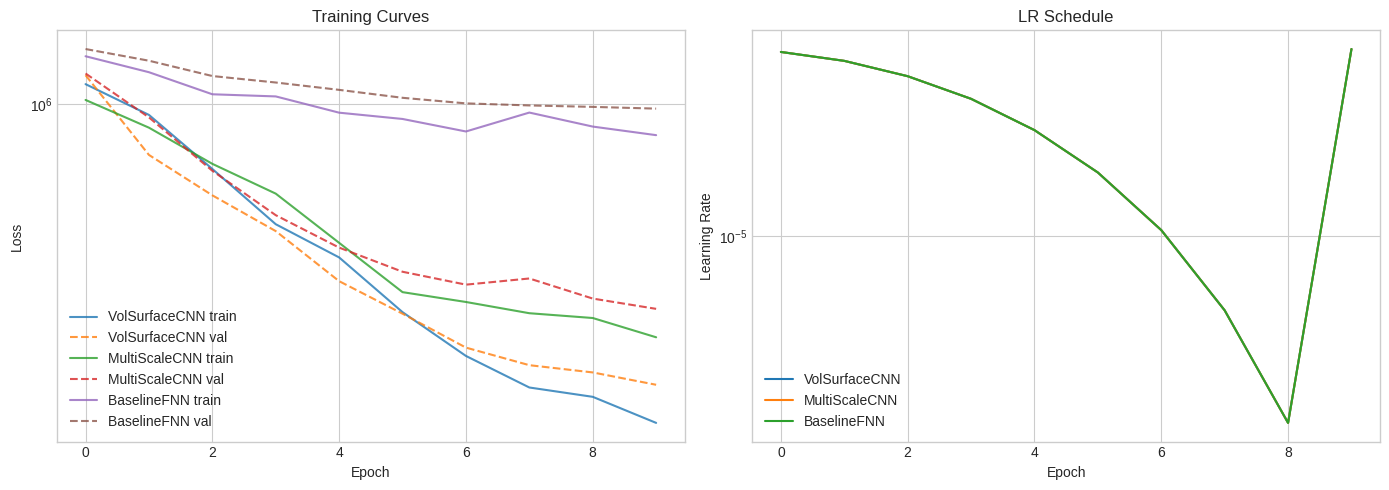

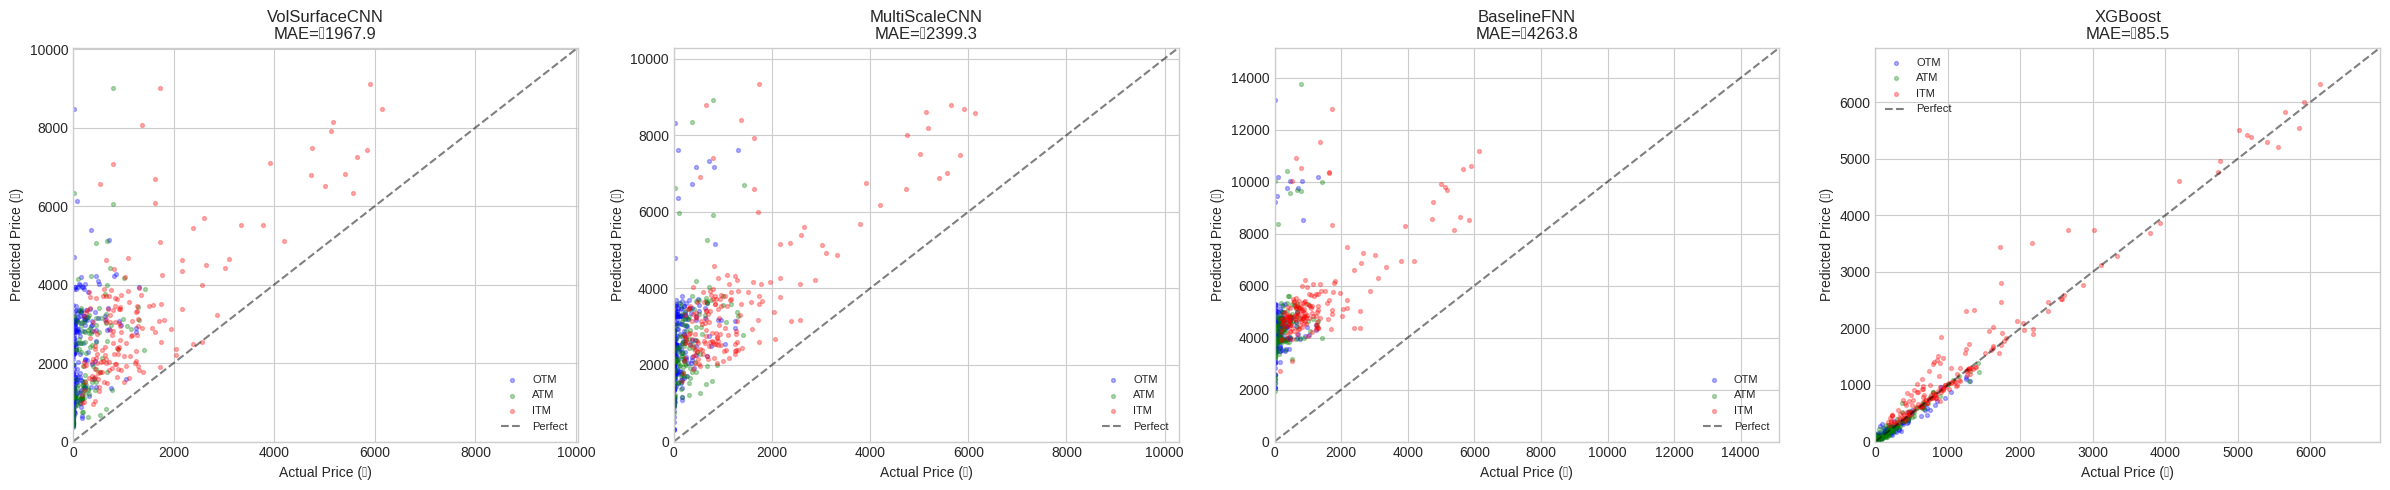

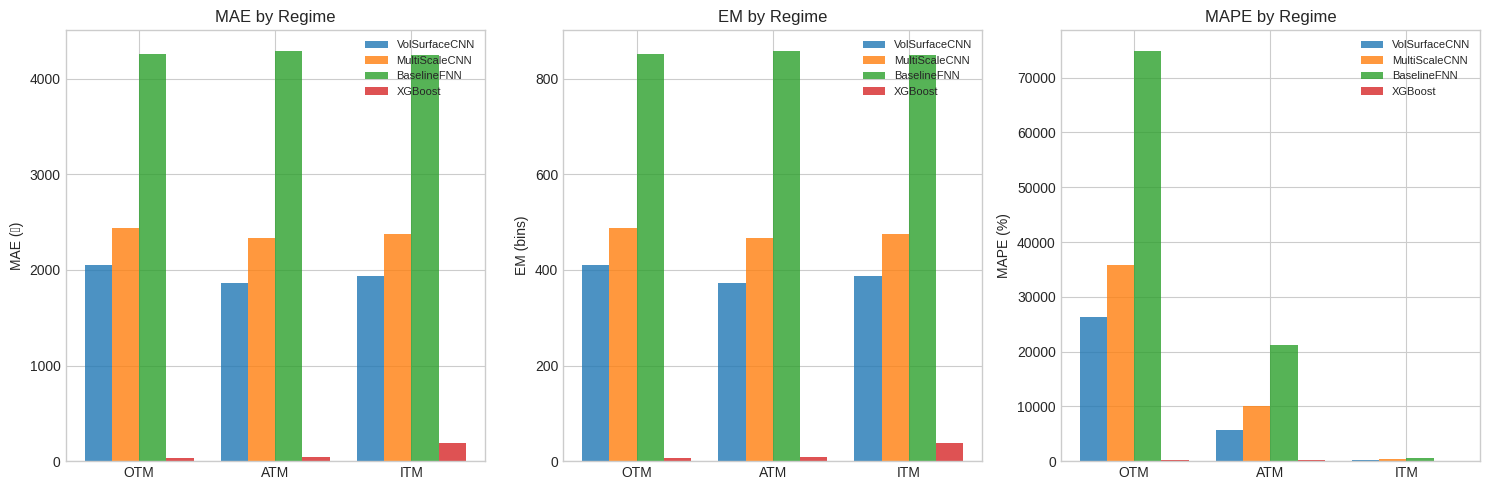

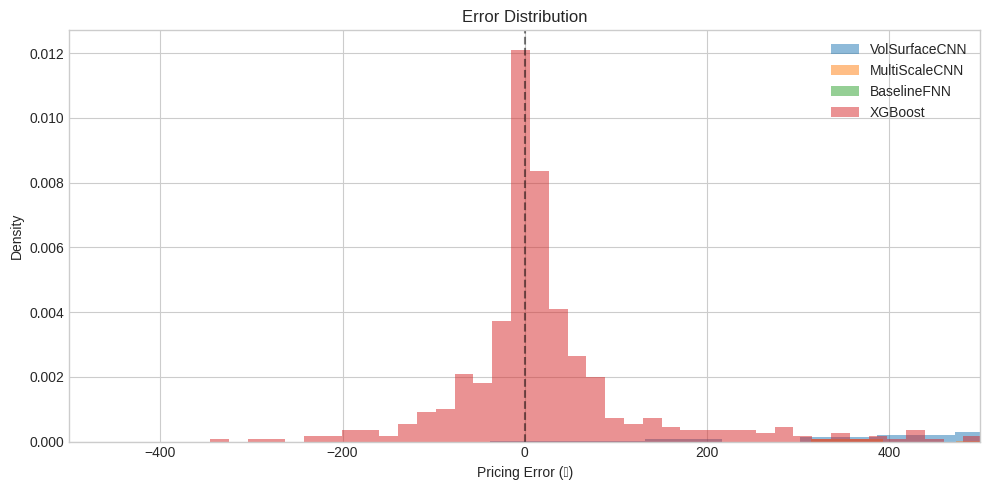


 Diebold-Mariano Tests:
 CNN vs FNN: {'dm_stat': np.float64(-80.58220665558025), 'p_value': np.float64(0.0), 'better': 'model2'}
 CNN vs XGBoost: {'dm_stat': np.float64(26.572960671818254), 'p_value': np.float64(0.0), 'better': 'model1'}
 VolSurfaceCNN MAE CI: 1970.03 [1877.59, 2068.32]
 MultiScaleCNN MAE CI: 2400.63 [2303.55, 2502.93]
 BaselineFNN MAE CI: 4261.82 [4150.45, 4382.39]
 XGBoost MAE CI: 85.53 [72.48, 100.69]
 VolSurfaceCNN: 1,338,957 parameters

 Portability: BANKNIFTY → NIFTY

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1275485.325059 1279640.433658   4.64e-06     ★ best
     2 1271701.984929 1273009.966608   4.37e-06     ★ best
     3 1258399.442967 1262736.136820   3.96e-06     ★ best
     4 1254696.126478 1259410.658392   3.44e-06     ★ best
     5 1244075.356087 1246209.673168   2.86e-06     ★ best
     7 1237465.470745 1241595.924350   1.77e-06     ★ best
  

KeyError: 'moneyness_cat'

In [ ]:
# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


**Reasoning**:
The previous execution failed because the `dummy_samples` created for feature importance calculation were missing the `moneyness_cat` key. I need to add a default `moneyness_cat` value to these dummy samples to prevent a `KeyError`.




RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 03:05:54,702] A new study created in memory with name: no-name-888c6f46-33f7-4e07-8901-17fc65f7aca2



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 1,639,303 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 149293.493416   0.219301   4.96e-03     ★ best
     5   0.213914   0.219301   2.54e-03           


[I 2026-03-12 03:06:01,488] Trial 0 finished with value: 0.21930066087192163 and parameters: {'lr': 0.005088059530676119, 'dropout': 0.2585873611394697, 'hidden_dim': 146, 'num_res_blocks': 4, 'mse_weight': 0.3023294514006757, 'rel_mse_weight': 0.25611459992364427, 'arbitrage_weight': 0.24318933587599212}. Best is trial 0 with value: 0.21930066087192163.


       Early stopping at epoch 6
 Training complete. Best val loss: 0.219301
 VolSurfaceCNN: 1,343,229 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 283835.126620   0.425468   5.31e-03     ★ best
     5   0.415157   0.425468   2.72e-03           


[I 2026-03-12 03:06:07,771] Trial 1 finished with value: 0.4254679072620277 and parameters: {'lr': 0.005444518324851015, 'dropout': 0.2628865713077151, 'hidden_dim': 132, 'num_res_blocks': 4, 'mse_weight': 0.45587580139378747, 'rel_mse_weight': 0.4973297347930709, 'arbitrage_weight': 0.10110546883779764}. Best is trial 0 with value: 0.21930066087192163.


       Early stopping at epoch 6
 Training complete. Best val loss: 0.425468
 VolSurfaceCNN: 522,766 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1318784.964516 1206203.797462   1.73e-05     ★ best
     2 1302615.079839 1193553.011748   1.61e-05     ★ best
     3 1285906.363306 1180264.425282   1.42e-05     ★ best
     4 1267937.516129 1171451.990132   1.19e-05     ★ best
     5 1252080.802419 1155525.881579   9.34e-06     ★ best
     6 1238960.089516 1135438.375940   6.77e-06     ★ best
     7 1218705.405645 1132621.070019   4.44e-06     ★ best
     8 1199653.412500 1113598.554041   2.59e-06     ★ best
     9 1196180.772177 1100597.955357   1.41e-06     ★ best


[I 2026-03-12 03:06:13,049] Trial 2 finished with value: 1100597.955357143 and parameters: {'lr': 1.7687260392543955e-05, 'dropout': 0.28296513888467173, 'hidden_dim': 94, 'num_res_blocks': 3, 'mse_weight': 0.5692131604976378, 'rel_mse_weight': 0.24972973296345, 'arbitrage_weight': 0.23270473208815795}. Best is trial 0 with value: 0.21930066087192163.


    10 1188912.345161 1102689.095395   1.77e-05           
 Training complete. Best val loss: 1100597.955357

 Best hyperparameters:
{'lr': 0.005088059530676119, 'dropout': 0.2585873611394697, 'hidden_dim': 146, 'num_res_blocks': 4, 'mse_weight': 0.3023294514006757, 'rel_mse_weight': 0.25611459992364427, 'arbitrage_weight': 0.24318933587599212}
 VolSurfaceCNN: 1,639,303 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 205566.465446   0.219301   4.96e-03     ★ best
     5   0.213005   0.219301   2.54e-03           
       Early stopping at epoch 6
 Training complete. Best val loss: 0.219301
 MultiScaleCNN: 475,685 parameters

 Training MultiScaleCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 206232.221590   0.219290   4.96e-03     ★ best
     5   0.213306   0.219301   2.54e-03          

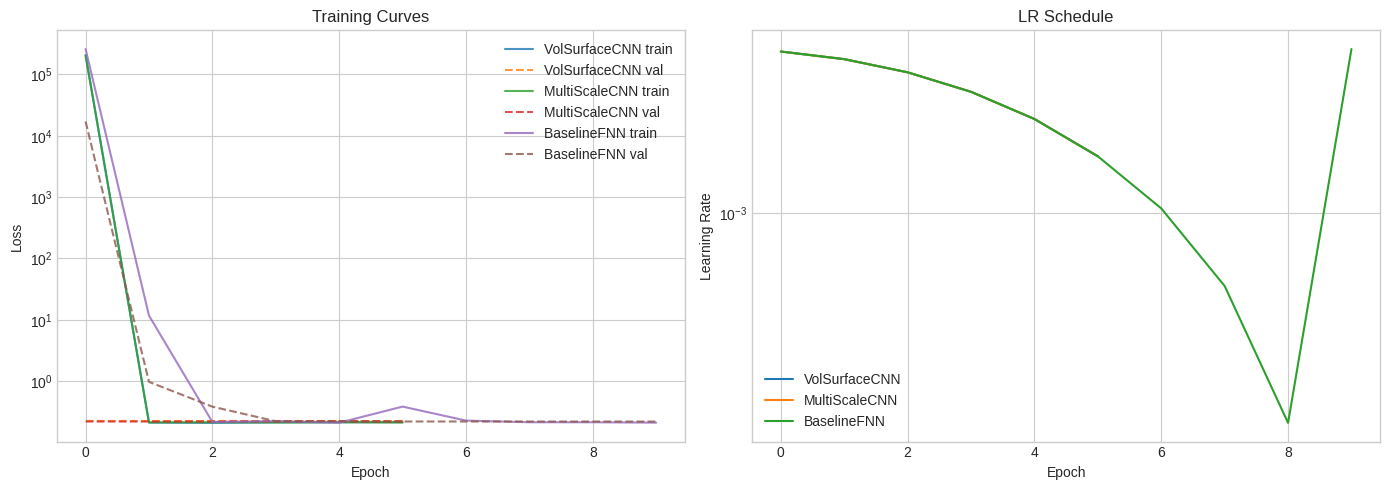

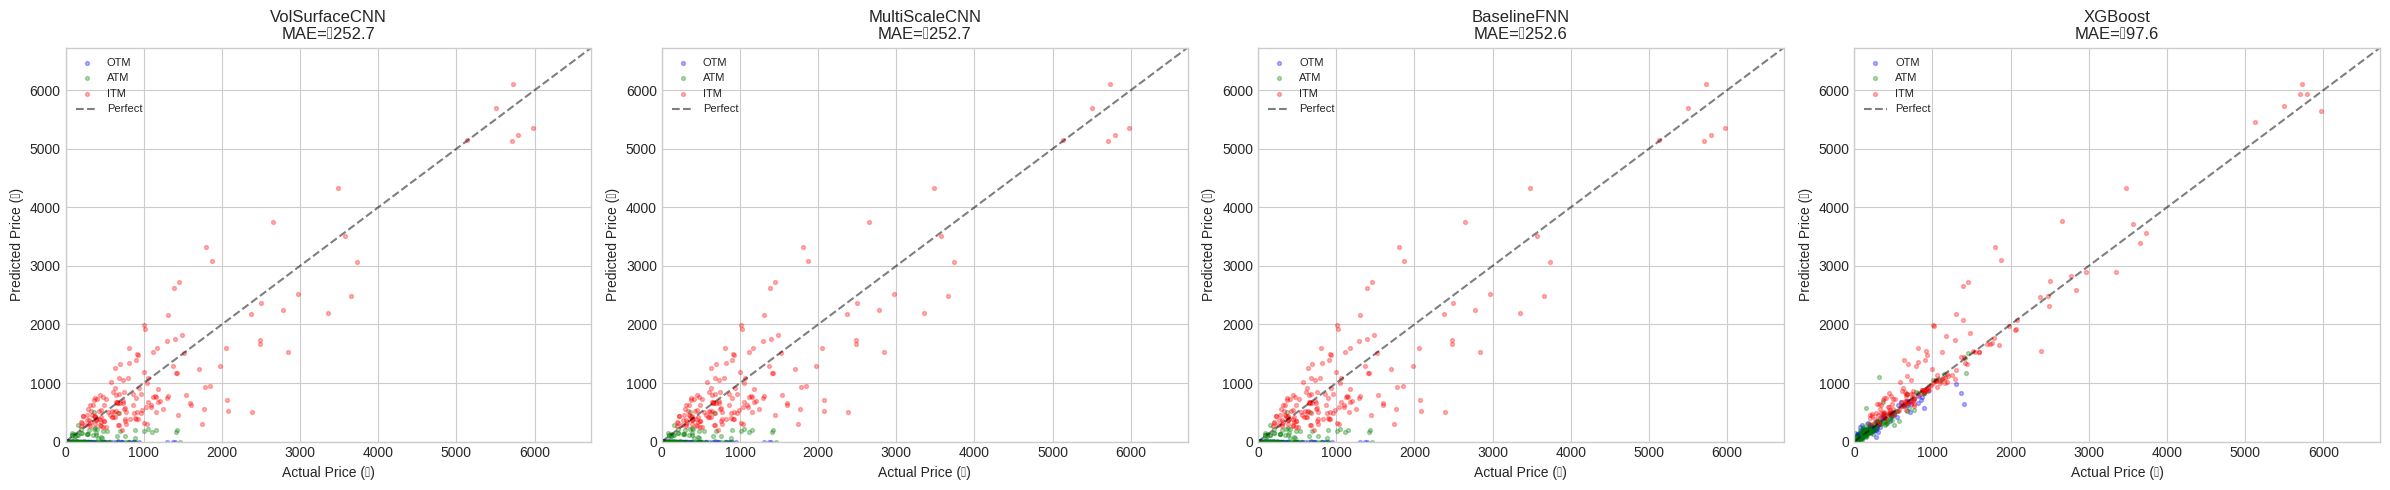

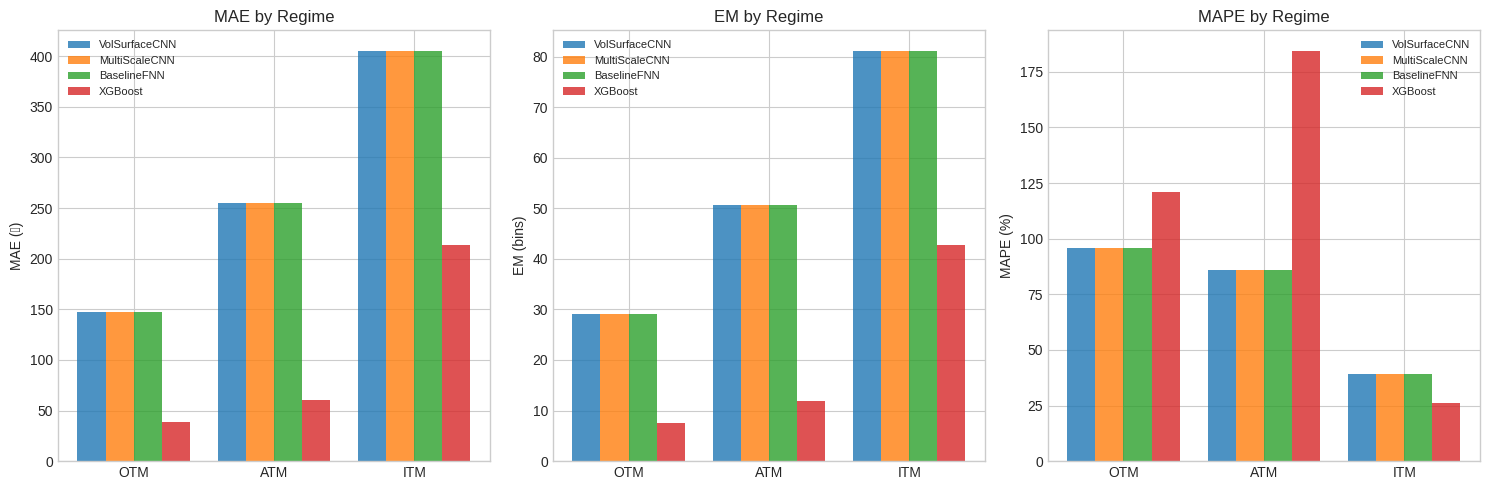

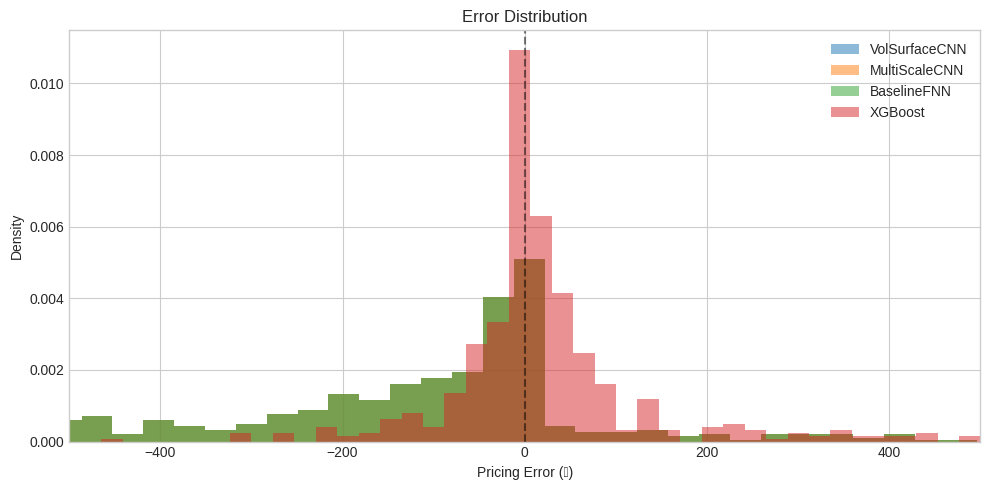


 Diebold-Mariano Tests:
 CNN vs FNN: {'dm_stat': np.float64(1.4486344208660789), 'p_value': np.float64(0.1474397033100303), 'better': 'not significant'}
 CNN vs XGBoost: {'dm_stat': np.float64(7.2798007937491125), 'p_value': np.float64(3.3439917501709715e-13), 'better': 'model1'}
 VolSurfaceCNN MAE CI: 252.62 [227.90, 279.34]
 MultiScaleCNN MAE CI: 253.61 [227.24, 282.13]
 BaselineFNN MAE CI: 252.37 [226.34, 277.70]
 XGBoost MAE CI: 97.81 [82.01, 114.91]
 VolSurfaceCNN: 1,639,303 parameters

 Portability: BANKNIFTY → NIFTY

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1247150.238623 989678.963579   4.96e-04     ★ best
     2 287131.962129  75.680037   4.60e-04     ★ best
     3   3.264359   0.261231   4.04e-04     ★ best
     5   0.261139   0.261331   2.55e-04           
     6   0.260846   0.261071   1.76e-04     ★ best
     8   0.260842   0.261053   4.95e-05     ★ best
     9

KeyError: 'moneyness_cat'

In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


**Reasoning**:
The previous execution failed because the `dummy_samples` created for feature importance calculation were missing the `moneyness_cat` key. I need to add a default `moneyness_cat` value to these dummy samples to prevent a `KeyError`.




RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 03:08:15,064] A new study created in memory with name: no-name-86890fe3-f7ed-4a1b-9cbd-2611f421be87



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 1,861,305 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1324517.238306 830270.253759   1.47e-04     ★ best
     2 574414.252923 280945.385632   1.37e-04     ★ best
     3 140842.350769 30344.196414   1.20e-04     ★ best
     4 11368.844065 859.130981   9.92e-05     ★ best
     5 328.312096   8.807281   7.60e-05     ★ best
     6  10.694141   0.575694   5.28e-05     ★ best
     7   0.602916   0.270566   3.19e-05     ★ best
     8   0.315836   0.261554   1.53e-05     ★ best


[I 2026-03-12 03:08:25,715] Trial 0 finished with value: 0.2615536384116438 and parameters: {'lr': 0.0001510630851087489, 'dropout': 0.22762237485935363, 'hidden_dim': 179, 'num_res_blocks': 3, 'mse_weight': 0.5787489677192639, 'rel_mse_weight': 0.315454120328117, 'arbitrage_weight': 0.22008826483503557}. Best is trial 0 with value: 0.2615536384116438.


    10   0.269636   0.263966   1.51e-04           
 Training complete. Best val loss: 0.261554
 VolSurfaceCNN: 4,581,703 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1130213.611127 19697.339543   3.39e-04     ★ best
     2 1004.567325   0.383331   3.15e-04     ★ best
     5   0.373979   0.383499   1.74e-04           


[I 2026-03-12 03:08:39,803] Trial 1 finished with value: 0.38333054525511606 and parameters: {'lr': 0.00034785277876710815, 'dropout': 0.28746966148871433, 'hidden_dim': 245, 'num_res_blocks': 4, 'mse_weight': 0.6044525303057462, 'rel_mse_weight': 0.44762608365069284, 'arbitrage_weight': 0.12206234988690262}. Best is trial 0 with value: 0.2615536384116438.


       Early stopping at epoch 7
 Training complete. Best val loss: 0.383331
 VolSurfaceCNN: 5,000,609 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 220819.898419   0.355122   2.22e-03     ★ best
     5   0.346511   0.355122   1.14e-03           


[I 2026-03-12 03:08:52,116] Trial 2 finished with value: 0.3551217378082132 and parameters: {'lr': 0.0022718888034670755, 'dropout': 0.22955020275655988, 'hidden_dim': 256, 'num_res_blocks': 4, 'mse_weight': 0.3852209173254239, 'rel_mse_weight': 0.4150862233545696, 'arbitrage_weight': 0.21787982256510696}. Best is trial 0 with value: 0.2615536384116438.


       Early stopping at epoch 6
 Training complete. Best val loss: 0.355122

 Best hyperparameters:
{'lr': 0.0001510630851087489, 'dropout': 0.22762237485935363, 'hidden_dim': 179, 'num_res_blocks': 3, 'mse_weight': 0.5787489677192639, 'rel_mse_weight': 0.315454120328117, 'arbitrage_weight': 0.22008826483503557}
 VolSurfaceCNN: 1,861,305 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1321564.933468 792605.279605   1.47e-04     ★ best
     2 476389.722177 195471.916295   1.37e-04     ★ best
     3 79103.631889 7956.156516   1.20e-04     ★ best
     4 3008.834273  47.000530   9.92e-05     ★ best
     5  26.467026   0.673186   7.60e-05     ★ best
     6   0.939463   0.265092   5.28e-05     ★ best
     7   0.267448   0.264343   3.19e-05     ★ best
    10   0.262707   0.266966   1.51e-04           
 Training complete. Best val loss: 0.264343
 MultiScaleCNN: 546,240 paramet

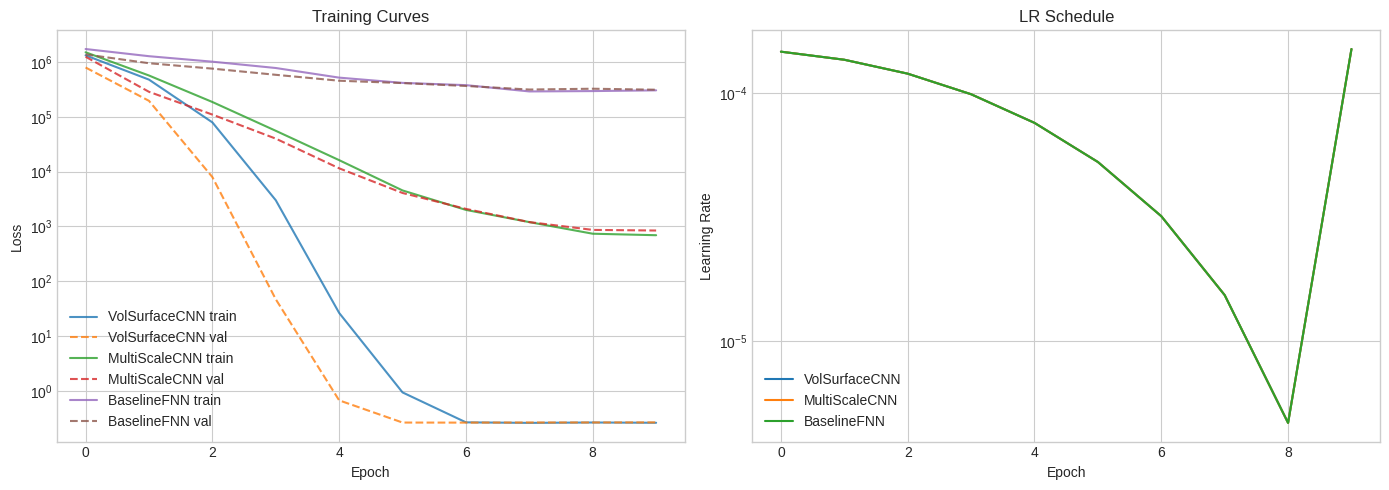

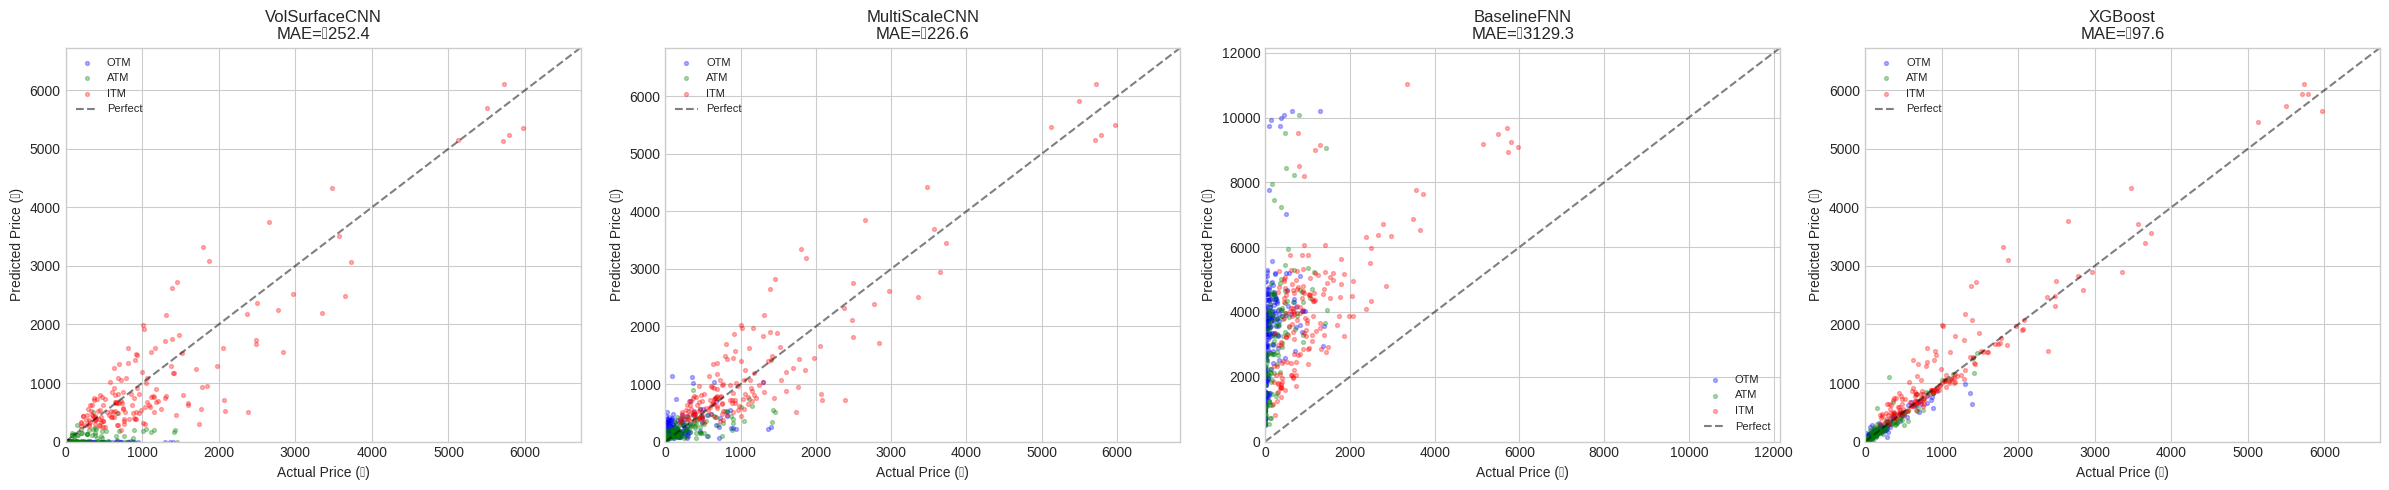

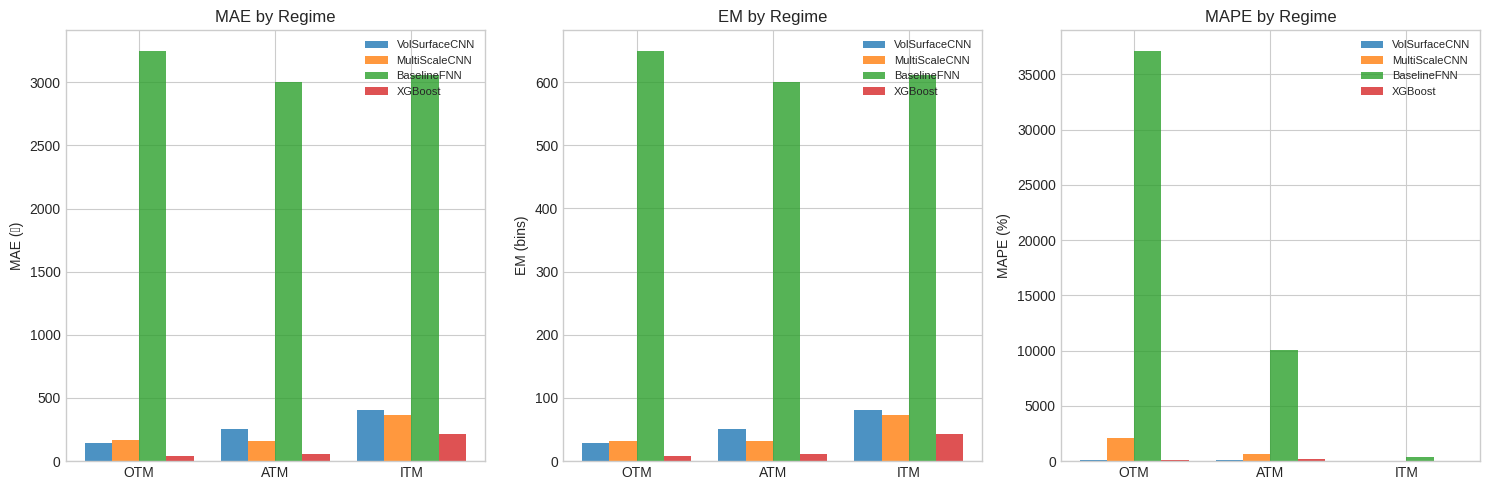

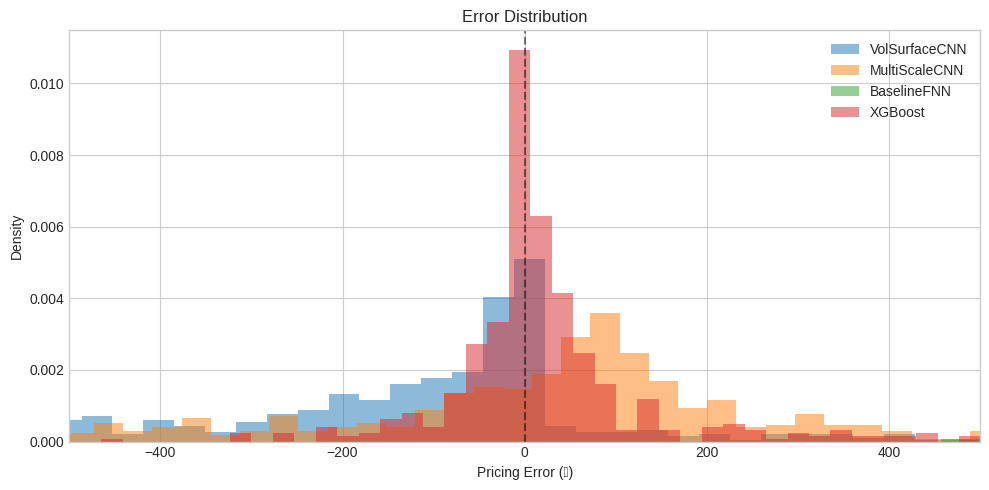


 Diebold-Mariano Tests:
 CNN vs FNN: {'dm_stat': np.float64(-34.18247042915226), 'p_value': np.float64(0.0), 'better': 'model2'}
 CNN vs XGBoost: {'dm_stat': np.float64(7.272652413970105), 'p_value': np.float64(3.526068326209497e-13), 'better': 'model1'}
 VolSurfaceCNN MAE CI: 252.31 [227.62, 279.03]
 MultiScaleCNN MAE CI: 227.38 [204.93, 249.73]
 BaselineFNN MAE CI: 3127.50 [2998.62, 3266.22]
 XGBoost MAE CI: 97.81 [82.01, 114.91]
 VolSurfaceCNN: 1,861,305 parameters

 Portability: BANKNIFTY → NIFTY

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1305625.379728 1291851.980644   1.48e-05     ★ best
     2 1269657.675827 1269574.407210   1.38e-05     ★ best
     3 1238349.057624 1241444.361407   1.22e-05     ★ best
     4 1215375.267287 1226711.506206   1.02e-05     ★ best
     5 1178113.229905 1175643.107270   8.05e-06     ★ best
     6 1134424.953310 1126913.862884   5.87e-06   

In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            ax.hist(errors, bins=100, alpha=0.5, label=name, density=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


**Reasoning**:
The previous execution failed with a KeyError because the `dummy_samples` list, used in `FeatureAnalyzer.occlusion_importance`, was missing the 'moneyness_cat' key. I will add a default 'moneyness_cat' value to these dummy samples to ensure compatibility with the `ErrorMetrics.compute` method.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            ax.hist(errors, bins=100, alpha=0.5, label=name, density=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }


**Reasoning**:
The previous execution failed due to a `KeyError` in the `FeatureAnalyzer` because the `dummy_samples` were missing the `moneyness_cat` key. I will update the `FeatureAnalyzer` class in `CELL 16` to include a default `moneyness_cat` of 1 in the `dummy_samples` when calling `metrics.compute`. This will resolve the error and allow the feature importance calculation to proceed correctly.




RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 03:14:14,168] A new study created in memory with name: no-name-571b21fc-668f-4891-9aeb-3138064cdc10



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 390,692 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 2737276.094355 2116139.989662   3.25e-04     ★ best
     2 1387176.214516 770539.571429   3.01e-04     ★ best
     3 404070.731250 84502.586701   2.64e-04     ★ best
     4 24158.616252 641.618056   2.18e-04     ★ best
     5 408.999059  11.318189   1.67e-04     ★ best
     6   5.719289   0.403932   1.16e-04     ★ best
     7   1.256605   0.389930   6.94e-05     ★ best


[I 2026-03-12 03:14:18,932] Trial 0 finished with value: 0.38993020075604434 and parameters: {'lr': 0.0003328778657060699, 'dropout': 0.2010753114926115, 'hidden_dim': 81, 'num_res_blocks': 3, 'mse_weight': 0.3836492169569875, 'rel_mse_weight': 0.46921641294554667, 'arbitrage_weight': 0.23511919579440652}. Best is trial 0 with value: 0.38993020075604434.


    10   0.412149   0.394434   3.33e-04           
 Training complete. Best val loss: 0.389930
 VolSurfaceCNN: 1,040,429 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1578696.977823 719678.896382   4.68e-04     ★ best
     2 117173.789127 167.518702   4.34e-04     ★ best
     3  22.424189   0.411990   3.81e-04     ★ best
     5   0.404879   0.415638   2.40e-04           


[I 2026-03-12 03:14:25,027] Trial 1 finished with value: 0.41199046664668204 and parameters: {'lr': 0.0004797273512596843, 'dropout': 0.3189941994569936, 'hidden_dim': 116, 'num_res_blocks': 4, 'mse_weight': 0.4103661608822374, 'rel_mse_weight': 0.48608721396064736, 'arbitrage_weight': 0.28489148819963583}. Best is trial 0 with value: 0.38993020075604434.


       Early stopping at epoch 8
 Training complete. Best val loss: 0.411990
 VolSurfaceCNN: 567,305 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1248225.229032 1010527.977679   2.14e-04     ★ best
     2 711127.142641 394868.098097   1.98e-04     ★ best
     3 271845.436240 120709.862430   1.74e-04     ★ best
     4 54212.058124 10645.863513   1.44e-04     ★ best
     5 3533.215279 179.381596   1.10e-04     ★ best
     6 243.799955  10.888511   7.63e-05     ★ best
     7  31.472225   2.326696   4.59e-05     ★ best
     8   5.127197   0.634037   2.18e-05     ★ best
     9   2.411357   0.312429   6.33e-06     ★ best


[I 2026-03-12 03:14:30,475] Trial 2 finished with value: 0.25208457945881035 and parameters: {'lr': 0.00021895249503939363, 'dropout': 0.20284938972376987, 'hidden_dim': 98, 'num_res_blocks': 3, 'mse_weight': 0.6219191134723507, 'rel_mse_weight': 0.22263036061391744, 'arbitrage_weight': 0.21916723206616778}. Best is trial 2 with value: 0.25208457945881035.


    10   1.531327   0.252085   2.19e-04     ★ best
 Training complete. Best val loss: 0.252085

 Best hyperparameters:
{'lr': 0.00021895249503939363, 'dropout': 0.20284938972376987, 'hidden_dim': 98, 'num_res_blocks': 3, 'mse_weight': 0.6219191134723507, 'rel_mse_weight': 0.22263036061391744, 'arbitrage_weight': 0.21916723206616778}
 VolSurfaceCNN: 567,305 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1118229.807661 971209.892857   2.14e-04     ★ best
     2 700079.106552 340254.932566   1.98e-04     ★ best
     3 266473.910938 137706.797462   1.74e-04     ★ best
     4 88347.252111 17756.117063   1.44e-04     ★ best
     5 11015.897166 1494.100709   1.10e-04     ★ best
     6 935.399622  81.248644   7.63e-05     ★ best
     7 135.274854  14.328020   4.59e-05     ★ best
     8  26.580592   3.203566   2.18e-05     ★ best
     9  10.463258   2.278906   6.33e-06     ★ be

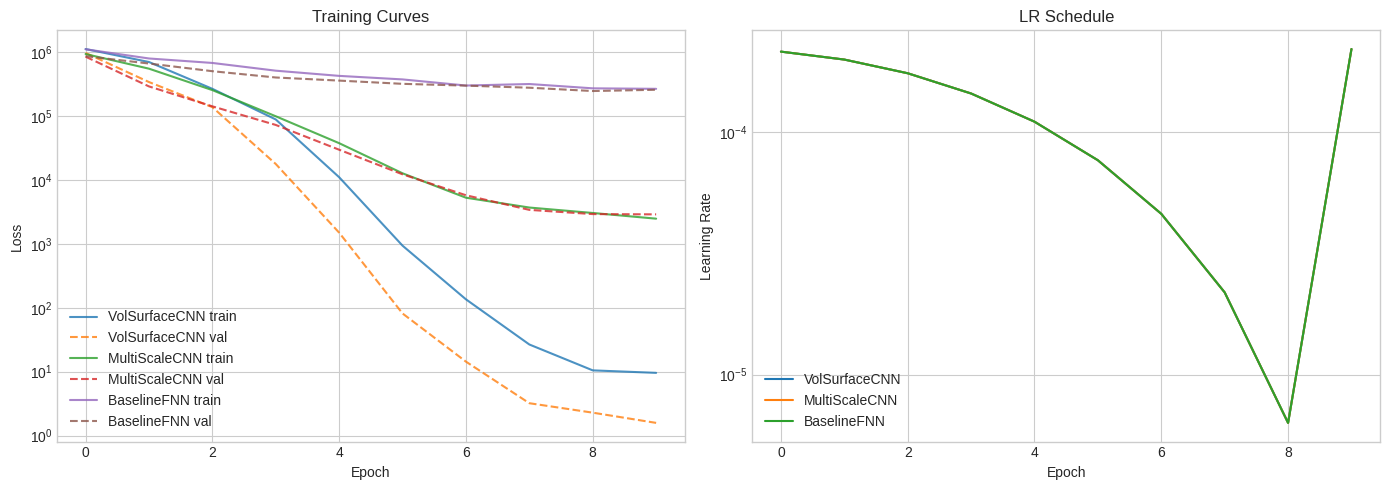

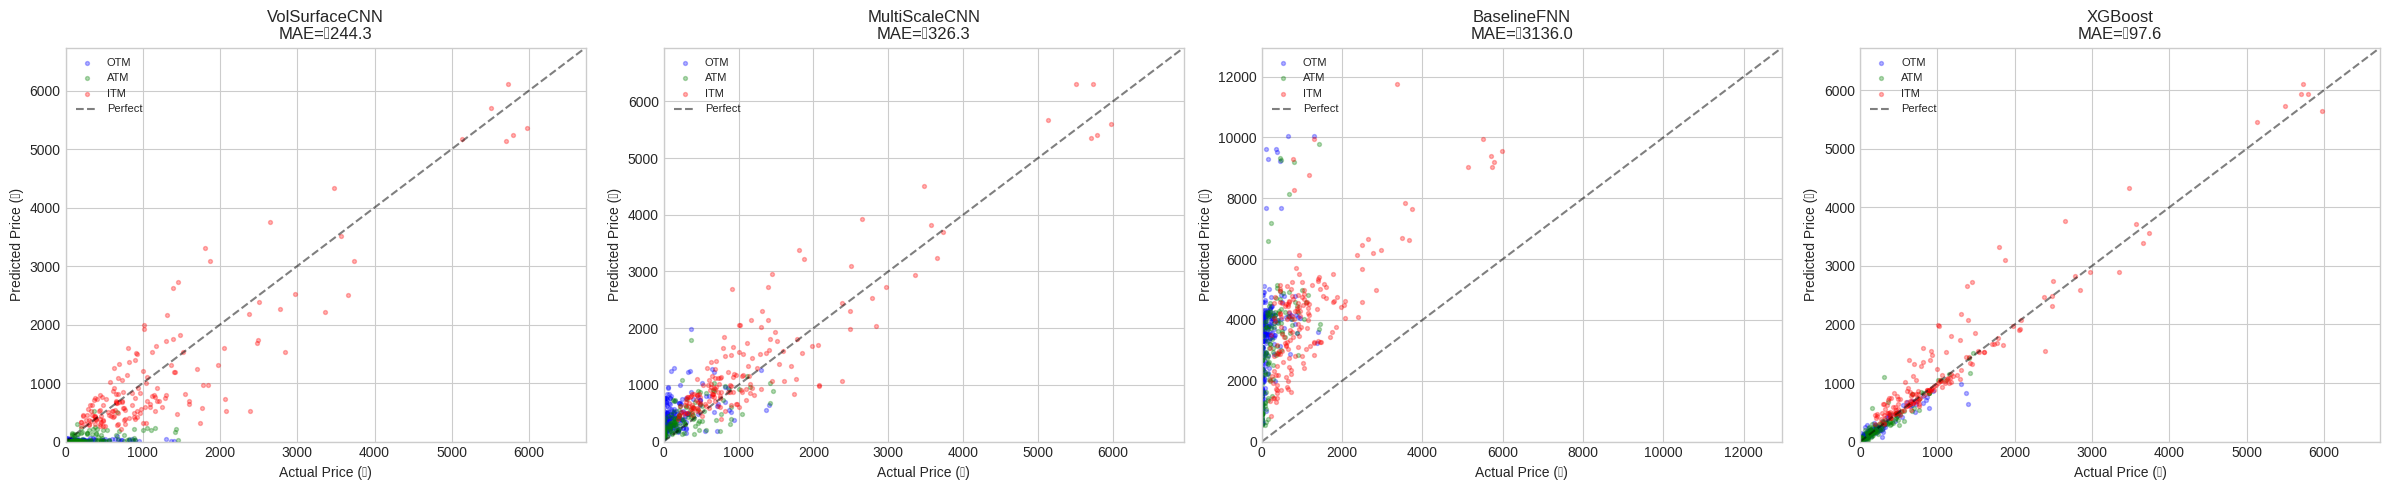

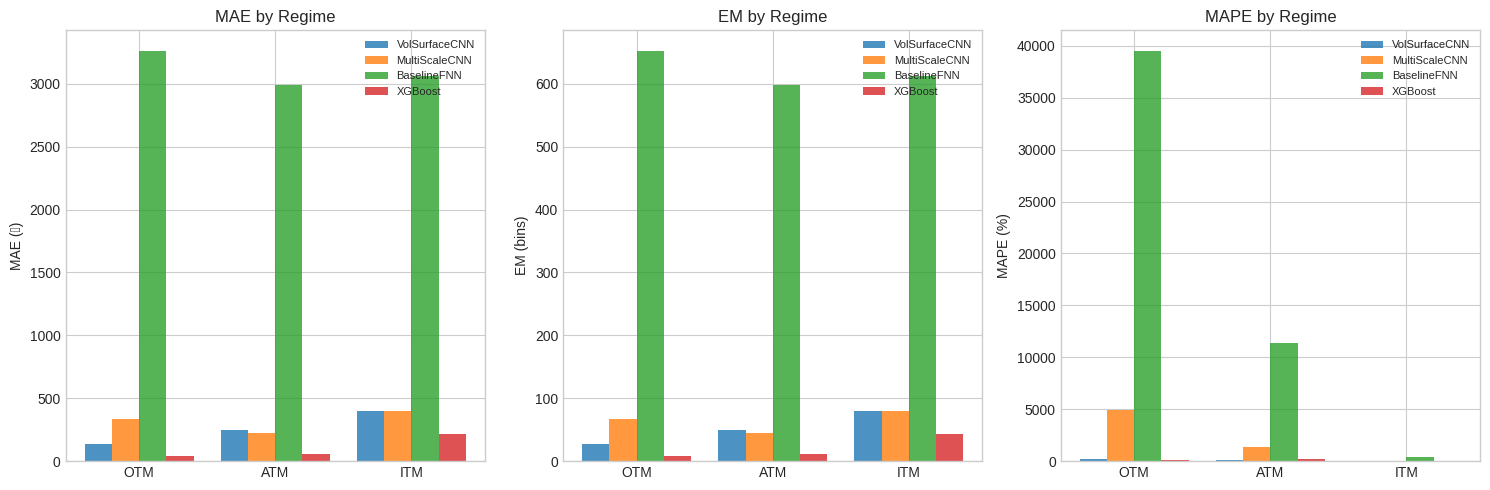

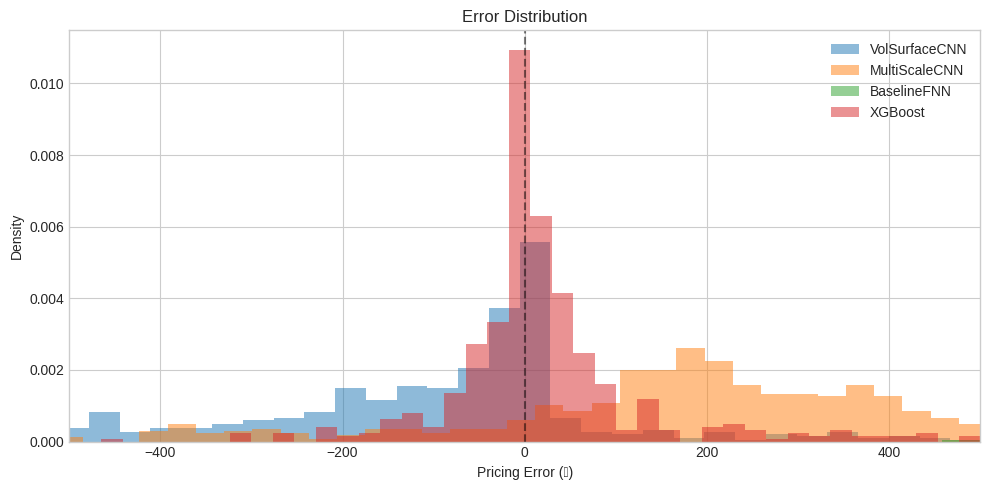


 Diebold-Mariano Tests:
 CNN vs FNN: {'dm_stat': np.float64(-37.03387696524219), 'p_value': np.float64(0.0), 'better': 'model2'}
 CNN vs XGBoost: {'dm_stat': np.float64(7.103957234888357), 'p_value': np.float64(1.212363542890671e-12), 'better': 'model1'}
 VolSurfaceCNN MAE CI: 244.25 [219.38, 270.69]
 MultiScaleCNN MAE CI: 327.06 [304.25, 350.94]
 BaselineFNN MAE CI: 3134.58 [3017.11, 3258.58]
 XGBoost MAE CI: 97.81 [82.01, 114.91]
 VolSurfaceCNN: 567,305 parameters

 Portability: BANKNIFTY → NIFTY

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1351193.924498 1345634.774084   2.14e-05     ★ best
     2 1326349.864953 1326404.641253   1.99e-05     ★ best
     3 1299838.278369 1298253.139037   1.76e-05     ★ best
     4 1276860.961732 1282789.706856   1.47e-05     ★ best
     5 1240679.583777 1231261.967790   1.14e-05     ★ best
     6 1195408.968972 1180882.363771   8.22e-06     

In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            ax.hist(errors, bins=100, alpha=0.5, label=name, density=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


**Reasoning**:
The previous execution failed with a KeyError because the `dummy_samples` list, used in `FeatureAnalyzer.occlusion_importance`, was missing the 'moneyness_cat' key. I will add a default `moneyness_cat` value to these dummy samples to prevent a `KeyError`.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            ax.hist(errors, bins=100, alpha=0.5, label=name, density=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = sym_actuals[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }


**Reasoning**:
The previous execution failed with a KeyError because the `dummy_samples` list, used in `FeatureAnalyzer.occlusion_importance`, was missing the 'moneyness_cat' key. I will update the `FeatureAnalyzer` class in `CELL 16` to include a default `moneyness_cat` of 1 in the `dummy_samples` when calling `metrics.compute`. This will resolve the error and allow the feature importance calculation to proceed correctly.




RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 03:24:07,733] A new study created in memory with name: no-name-f061a57a-73b3-4e1a-ac8f-e9ca646850dc



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 175,871 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 2519813.743548 2296575.341165   2.93e-05     ★ best
     2 2484854.240323 2272802.159774   2.73e-05     ★ best
     3 2448543.654839 2243125.105263   2.40e-05     ★ best
     4 2418896.025806 2210106.912594   2.00e-05     ★ best
     5 2385521.117742 2190499.449248   1.55e-05     ★ best
     6 2344934.170968 2153482.864662   1.10e-05     ★ best
     7 2325968.891935 2124890.461466   6.98e-06     ★ best
     8 2294791.664516 2096729.355263   3.77e-06     ★ best


[I 2026-03-12 03:24:12,158] Trial 0 finished with value: 2092287.8068609023 and parameters: {'lr': 3.0026027831115796e-05, 'dropout': 0.27724109963111554, 'hidden_dim': 65, 'num_res_blocks': 2, 'mse_weight': 0.37389666445533265, 'rel_mse_weight': 0.418096575331387, 'arbitrage_weight': 0.21354100601154763}. Best is trial 0 with value: 2092287.8068609023.


    10 2276115.072581 2092287.806861   3.00e-05     ★ best
 Training complete. Best val loss: 2092287.806861
 VolSurfaceCNN: 2,290,569 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 259209.891087   0.208359   1.93e-03     ★ best
     5   0.203154   0.208359   9.91e-04           


[I 2026-03-12 03:24:21,077] Trial 1 finished with value: 0.20835923969297482 and parameters: {'lr': 0.0019804352649645273, 'dropout': 0.3645662206412891, 'hidden_dim': 155, 'num_res_blocks': 5, 'mse_weight': 0.3691809458052888, 'rel_mse_weight': 0.24306140381072566, 'arbitrage_weight': 0.23421950915444278}. Best is trial 1 with value: 0.20835923969297482.


       Early stopping at epoch 6
 Training complete. Best val loss: 0.208359
 VolSurfaceCNN: 4,960,166 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 2013753.439516 1866148.314850   3.74e-05     ★ best
     2 1716019.108871 1315078.716165   3.47e-05     ★ best
     3 961899.970565 539428.097509   3.06e-05     ★ best
     4 518159.856048 351973.033247   2.54e-05     ★ best
     5 292282.066129 162658.866277   1.97e-05     ★ best
     6 155453.709073 92462.277946   1.39e-05     ★ best
     7 92318.258947 51804.637593   8.69e-06     ★ best
     8 57142.503427 46848.128043   4.56e-06     ★ best
     9 43643.522051 34803.225847   1.91e-06     ★ best


[I 2026-03-12 03:24:41,477] Trial 2 finished with value: 34803.22584659892 and parameters: {'lr': 3.830116815091512e-05, 'dropout': 0.3743305059485267, 'hidden_dim': 255, 'num_res_blocks': 4, 'mse_weight': 0.6783000355297721, 'rel_mse_weight': 0.3961453650928523, 'arbitrage_weight': 0.18893200230821156}. Best is trial 1 with value: 0.20835923969297482.


    10 38666.320413 36198.678961   3.83e-05           
 Training complete. Best val loss: 34803.225847

 Best hyperparameters:
{'lr': 0.0019804352649645273, 'dropout': 0.3645662206412891, 'hidden_dim': 155, 'num_res_blocks': 5, 'mse_weight': 0.3691809458052888, 'rel_mse_weight': 0.24306140381072566, 'arbitrage_weight': 0.23421950915444278}
 VolSurfaceCNN: 2,290,569 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 316455.931566   0.208358   1.93e-03     ★ best
     5   0.203692   0.208359   9.91e-04           
       Early stopping at epoch 6
 Training complete. Best val loss: 0.208358
 MultiScaleCNN: 654,820 parameters

 Training MultiScaleCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 333859.382214   2.837179   1.93e-03     ★ best
     2   0.202461   0.208254   1.79e-03     ★ best
   

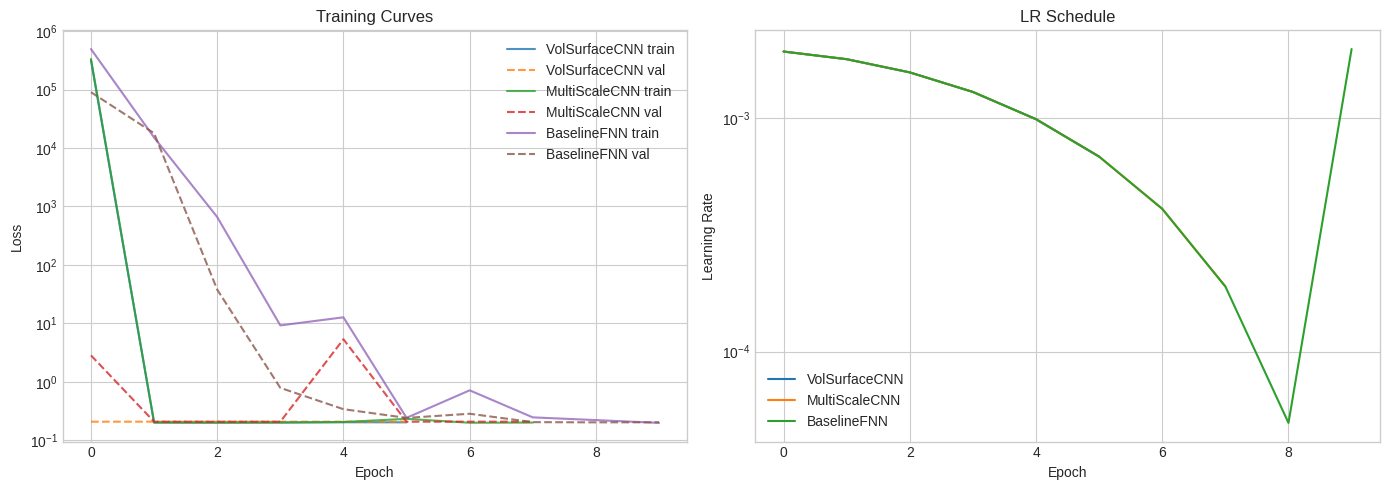

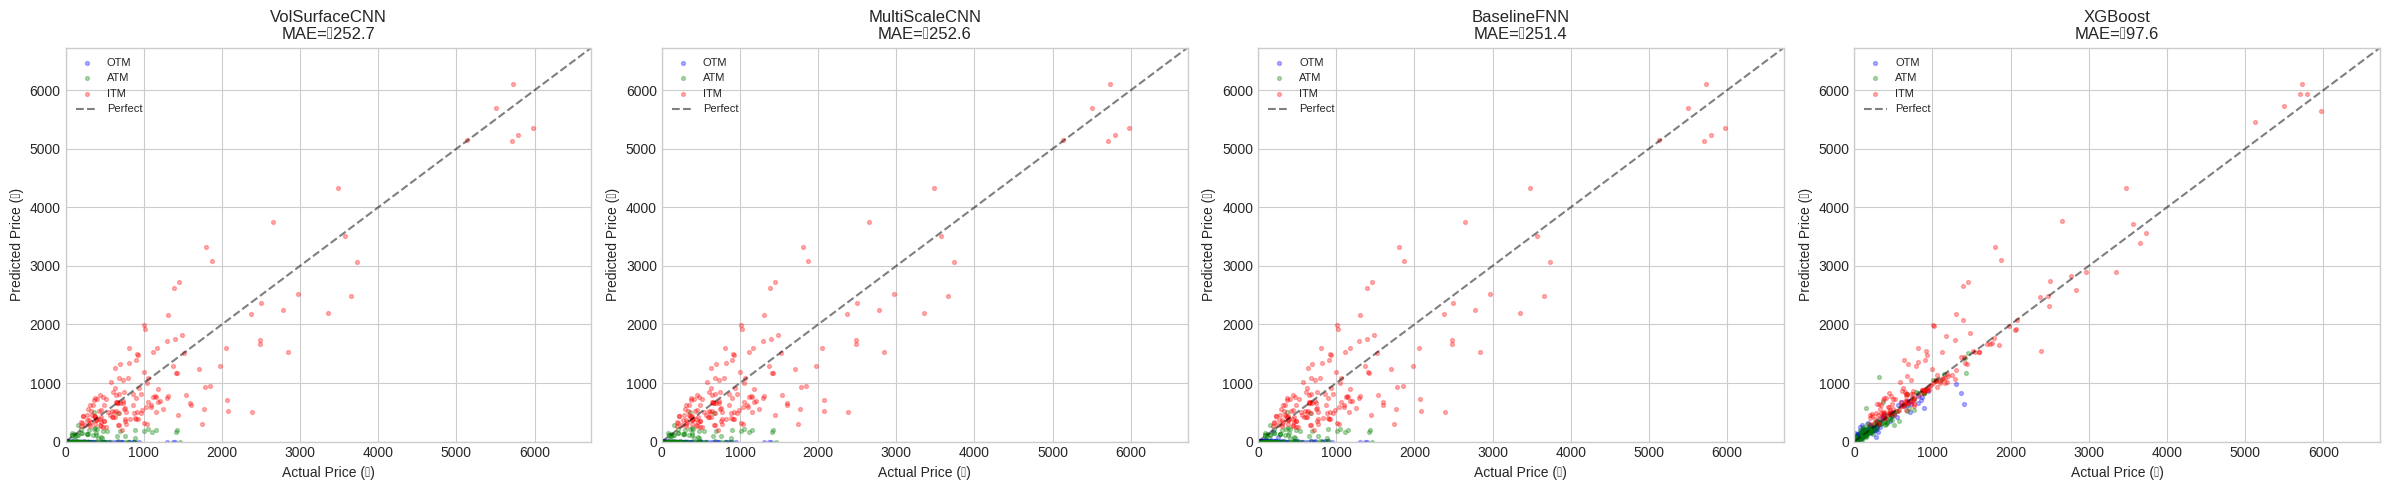

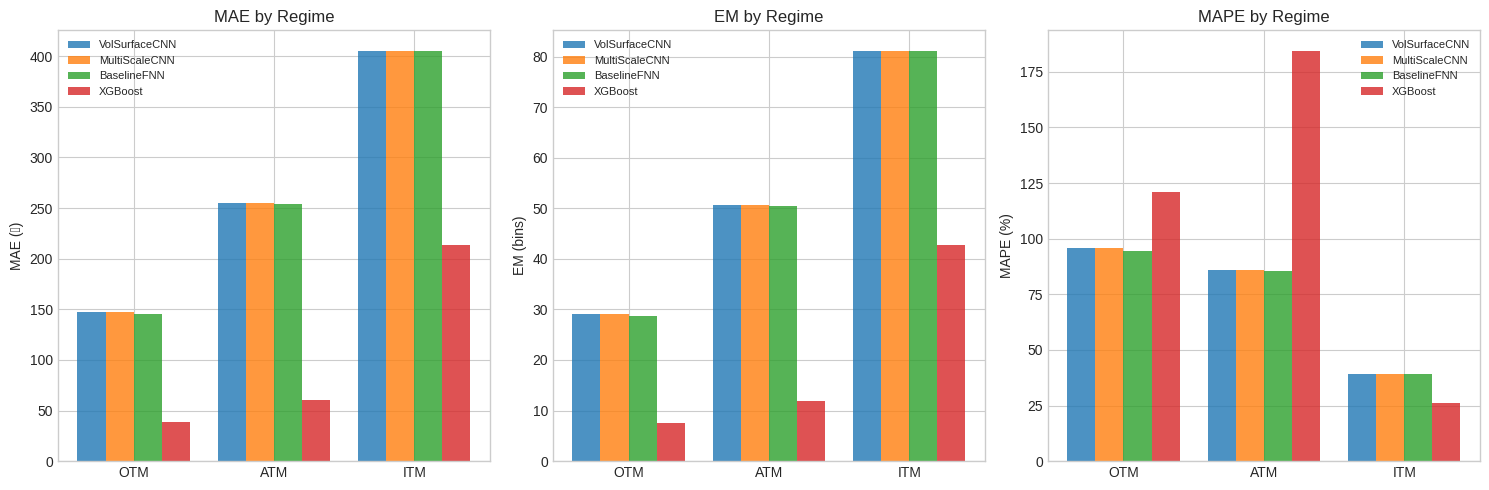

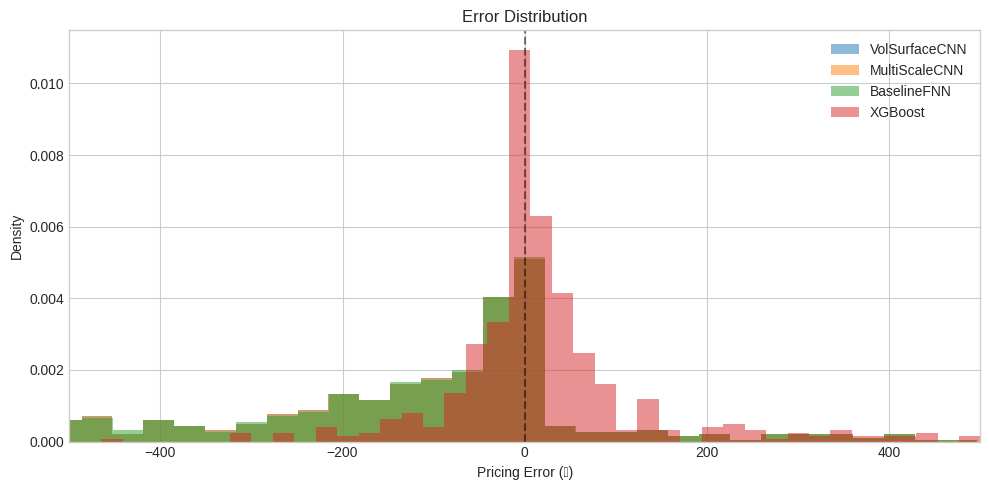


 Diebold-Mariano Tests:
 CNN vs FNN: {'dm_stat': np.float64(5.459203310446683), 'p_value': np.float64(4.782758322718905e-08), 'better': 'model1'}
 CNN vs XGBoost: {'dm_stat': np.float64(7.279800598541521), 'p_value': np.float64(3.3439917501709715e-13), 'better': 'model1'}
 VolSurfaceCNN MAE CI: 252.62 [227.90, 279.34]
 MultiScaleCNN MAE CI: 253.60 [227.22, 282.11]
 BaselineFNN MAE CI: 251.16 [224.90, 276.47]
 XGBoost MAE CI: 97.81 [82.01, 114.91]
 VolSurfaceCNN: 2,290,569 parameters

 Portability: BANKNIFTY → NIFTY

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1056863.999187 792797.792036   1.93e-04     ★ best
     2 201583.934841 2471.942065   1.79e-04     ★ best
     3 1067.621249   1.466465   1.57e-04     ★ best
     4   1.405290   0.537577   1.30e-04     ★ best
     5   5.116233   0.259813   9.95e-05     ★ best
     6   0.261070   0.259371   6.91e-05     ★ best
    10   0.2

In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            ax.hist(errors, bins=100, alpha=0.5, label=name, density=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


**Reasoning**:
The previous execution failed with a KeyError because the `dummy_samples` list, used in `FeatureAnalyzer.occlusion_importance`, was missing the 'moneyness_cat' key. I will update the `FeatureAnalyzer` class in `CELL 16` to include a default `moneyness_cat` of 1 in the `dummy_samples` when calling `metrics.compute`. This will resolve the error and allow the feature importance calculation to proceed correctly.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }


**Reasoning**:
The previous execution failed due to a `KeyError` in the `FeatureAnalyzer` because the `dummy_samples` were missing the `moneyness_cat` key. I will add a default `moneyness_cat` value to these dummy samples to prevent a `KeyError` and re-run the `FeatureAnalyzer` cell.




RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 03:29:20,529] A new study created in memory with name: no-name-fbf261ee-8cea-4ed6-93ab-fbe52b4d3bb2



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 2,940,989 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 387419.053335   0.420256   3.16e-03     ★ best
     5   0.410066   0.420256   1.62e-03           


[I 2026-03-12 03:29:30,002] Trial 0 finished with value: 0.42025556443329143 and parameters: {'lr': 0.003243124663912115, 'dropout': 0.3991255494917485, 'hidden_dim': 196, 'num_res_blocks': 4, 'mse_weight': 0.45502839412743057, 'rel_mse_weight': 0.49122113644513027, 'arbitrage_weight': 0.2952093225287217}. Best is trial 0 with value: 0.42025556443329143.


       Early stopping at epoch 6
 Training complete. Best val loss: 0.420256
 VolSurfaceCNN: 637,847 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 568245.567689  52.241756   1.52e-03     ★ best
     2   0.612679   0.231180   1.41e-03     ★ best
     5   0.225187   0.231180   7.82e-04           


[I 2026-03-12 03:29:33,957] Trial 1 finished with value: 0.23118031428272562 and parameters: {'lr': 0.001562232213932773, 'dropout': 0.3509139209704838, 'hidden_dim': 104, 'num_res_blocks': 3, 'mse_weight': 0.6137871289201886, 'rel_mse_weight': 0.2689979967969238, 'arbitrage_weight': 0.18320086704901778}. Best is trial 1 with value: 0.23118031428272562.


       Early stopping at epoch 7
 Training complete. Best val loss: 0.231180
 VolSurfaceCNN: 175,871 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1094405.421371 982880.543468   1.33e-04     ★ best
     2 999849.782258 832817.983083   1.23e-04     ★ best
     3 839773.180040 605292.400611   1.08e-04     ★ best
     4 665325.486694 517455.759868   8.92e-05     ★ best
     5 529424.727419 384120.792998   6.84e-05     ★ best
     6 430761.041532 323080.820724   4.76e-05     ★ best
     7 361400.681452 268498.815202   2.88e-05     ★ best
     8 321073.386290 239046.738663   1.39e-05     ★ best
     9 294559.290423 226255.638628   4.30e-06     ★ best


[I 2026-03-12 03:29:38,239] Trial 2 finished with value: 219443.5814732143 and parameters: {'lr': 0.00013580311725151377, 'dropout': 0.2947882691788948, 'hidden_dim': 65, 'num_res_blocks': 2, 'mse_weight': 0.3546989948124295, 'rel_mse_weight': 0.22586675019371974, 'arbitrage_weight': 0.29427115024807127}. Best is trial 1 with value: 0.23118031428272562.


    10 289379.860282 219443.581473   1.36e-04     ★ best
 Training complete. Best val loss: 219443.581473

 Best hyperparameters:
{'lr': 0.001562232213932773, 'dropout': 0.3509139209704838, 'hidden_dim': 104, 'num_res_blocks': 3, 'mse_weight': 0.6137871289201886, 'rel_mse_weight': 0.2689979967969238, 'arbitrage_weight': 0.18320086704901778}
 VolSurfaceCNN: 637,847 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 544068.457932   0.810786   1.52e-03     ★ best
     2   1.643533   0.231180   1.41e-03     ★ best
     5   0.225654   0.231180   7.82e-04           
       Early stopping at epoch 7
 Training complete. Best val loss: 0.231180
 MultiScaleCNN: 193,065 parameters

 Training MultiScaleCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 558777.645174 9795.638892   1.52e-03     ★ best
   

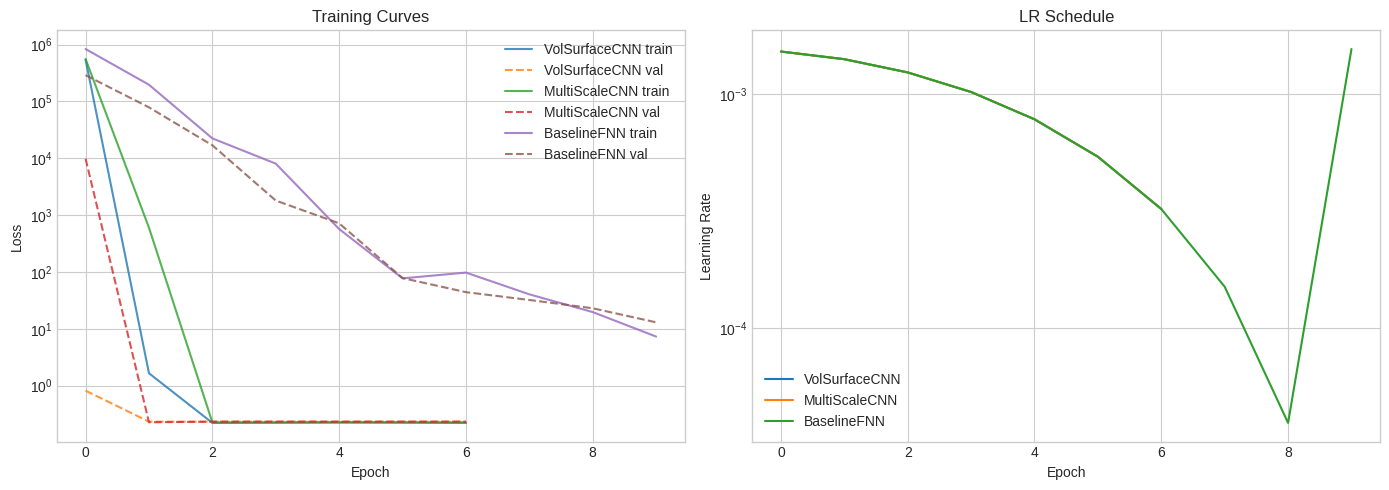

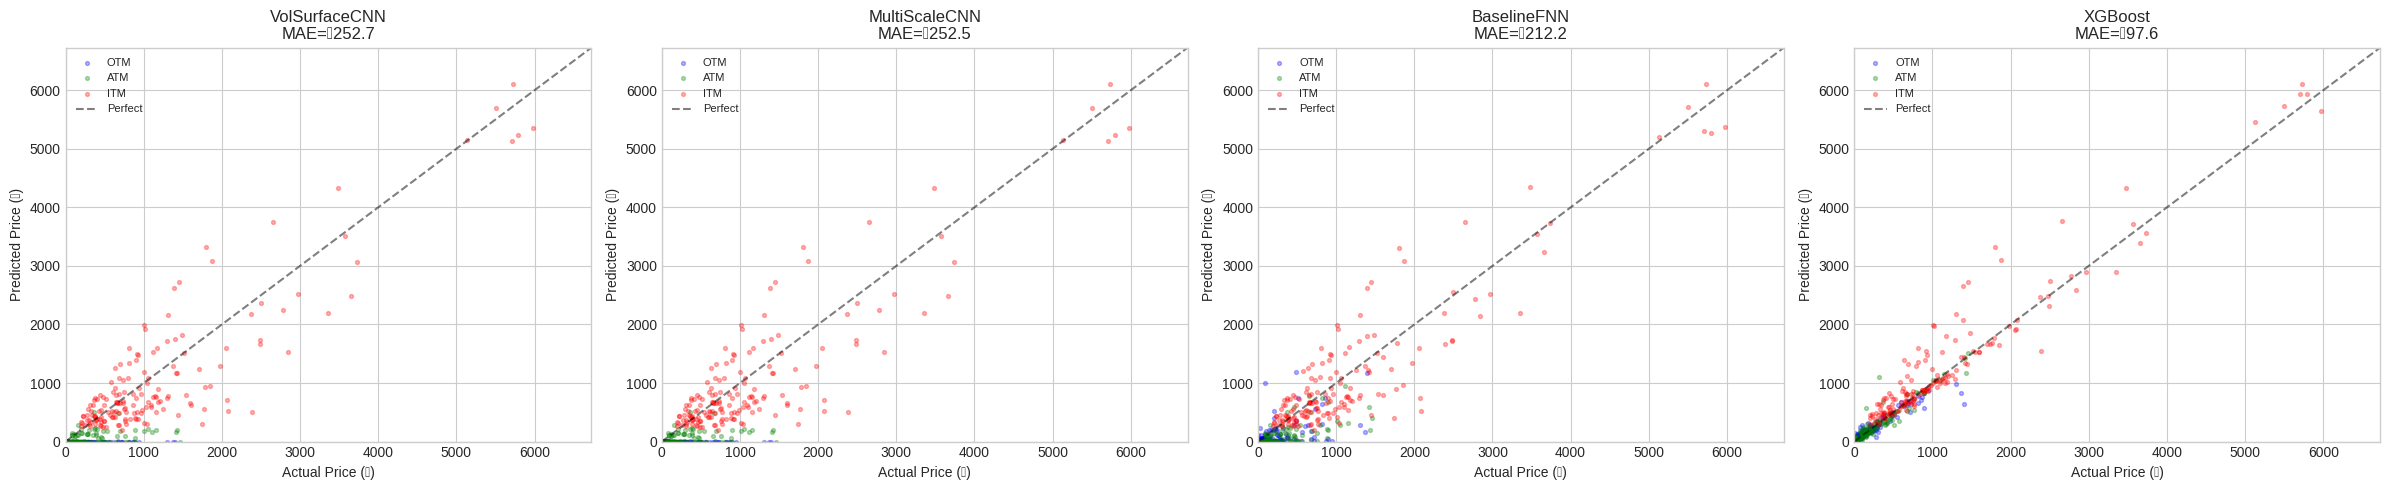

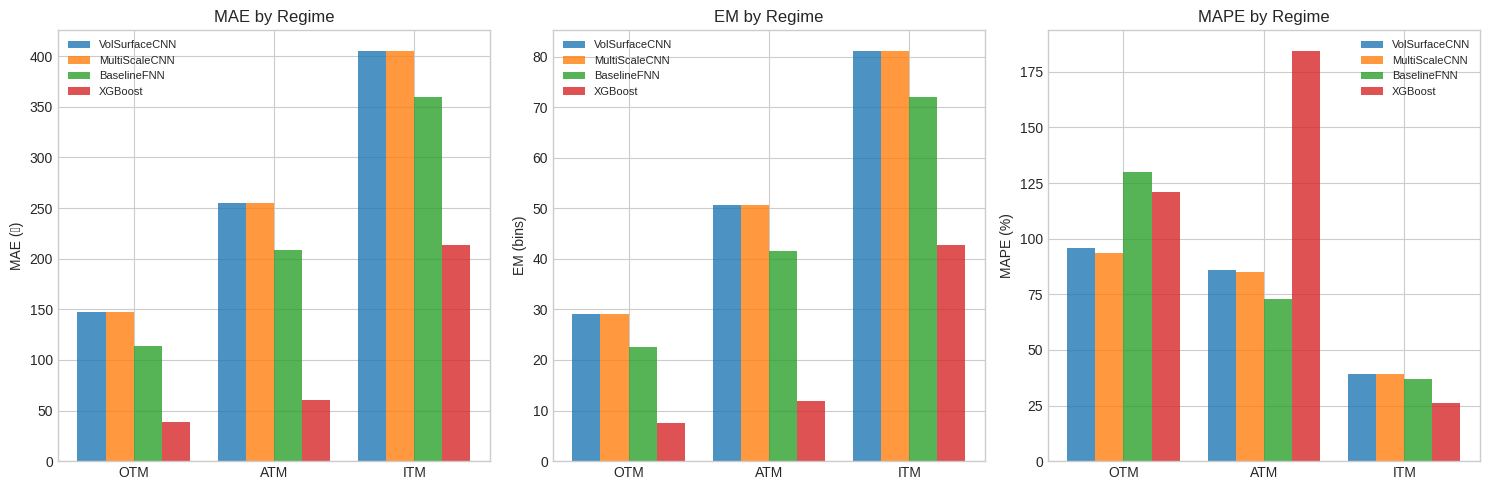

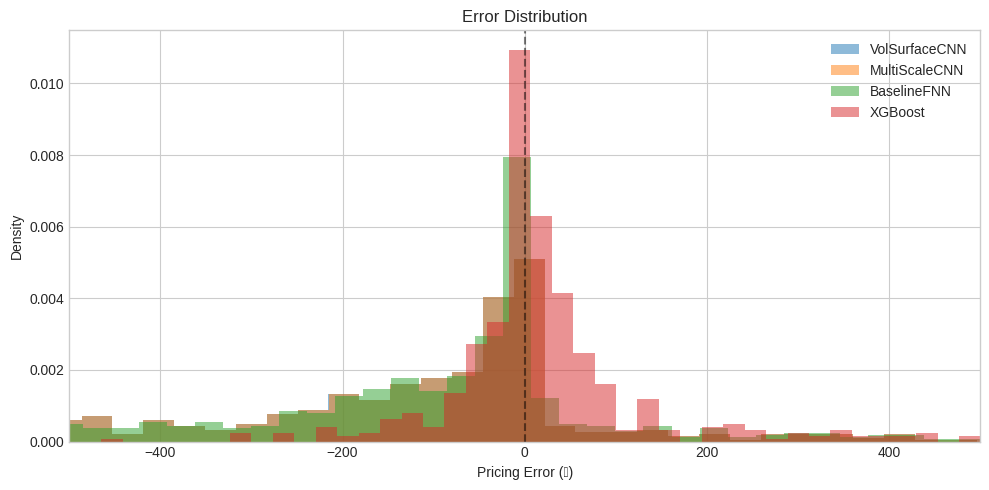


 Diebold-Mariano Tests:
 CNN vs FNN: {'dm_stat': np.float64(4.080355245770612), 'p_value': np.float64(4.496692516875456e-05), 'better': 'model1'}
 CNN vs XGBoost: {'dm_stat': np.float64(7.27979859479262), 'p_value': np.float64(3.3439917501709715e-13), 'better': 'model1'}
 VolSurfaceCNN MAE CI: 252.62 [227.90, 279.34]
 MultiScaleCNN MAE CI: 253.49 [227.12, 282.01]
 BaselineFNN MAE CI: 212.11 [189.38, 235.09]
 XGBoost MAE CI: 97.81 [82.01, 114.91]
 VolSurfaceCNN: 637,847 parameters

 Portability: BANKNIFTY → NIFTY

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 1154375.161643 1087167.913121   1.52e-04     ★ best
     2 780347.282284 656434.777335   1.41e-04     ★ best
     3 366202.914155 252057.056257   1.24e-04     ★ best
     4 138897.880282 62127.682070   1.03e-04     ★ best
     5 28454.030672 6740.962623   7.86e-05     ★ best
     6 6765.943075 1187.621523   5.46e-05     ★ be

In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            ax.hist(errors, bins=100, alpha=0.5, label=name, density=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


**Reasoning**:
The previous execution failed due to a KeyError in the FeatureAnalyzer because the `dummy_samples` were missing the 'moneyness_cat' key. I will update the `FeatureAnalyzer` class in `CELL 16` to include a default `moneyness_cat` of 1 in the `dummy_samples` when calling `metrics.compute`. This will resolve the error and allow the feature importance calculation to proceed correctly.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + i * width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            sns.histplot(errors, bins=100, alpha=0.5, label=name, ax=ax, kde=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and re`return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


**Reasoning**:
The previous execution failed with a KeyError because the `dummy_samples` list, used in `FeatureAnalyzer.occlusion_importance`, was missing the 'moneyness_cat' key. I will update the `FeatureAnalyzer` class in `CELL 16` to include a default `moneyness_cat` of 1 in the `dummy_samples` when calling `metrics.compute`. This will resolve the error and allow the feature importance calculation to proceed correctly.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            sns.histplot(errors, bins=100, alpha=0.5, label=name, ax=ax, kde=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)



RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 Spots loaded: 2081 rows, 2013-12-26 to 2018-03-26
 Symbols: ['NIFTY', 'BANKNIFTY']
 Options loaded: 327770 rows
 Merged: 80664/327770 rows matched with spot (24.6%)

 Final dataset: 327770 rows
 Columns: ['Instrument', 'Symbol', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Settlement', 'Volume', 'Turnover', 'OI', 'Change_OI', 'Date', 'Unnamed: 15', 'LTP', 'TTM', 'Spot']
 Date range: 2014-01-01 00:00:00 to 2018-12-03 00:00:00
 Symbols: {'NIFTY': 252289, 'BANKNIFTY': 75481}

════════════════════════════════════════════════════════════
ATROPY-STYLE DATA CLEANING
════════════════════════════════════════════════════════════
 [1] Positive prices: 327770 → 177891 (removed 149879)
 [2] OHLC consistency: 177891 → 177891 (removed 0)
 [3] Volume/OI > 0: 177891 → 154330 (removed 23561)
 [4] TTM in (0,365]: 15

[I 2026-03-12 04:22:42,457] A new study created in memory with name: no-name-4d96bfe1-dc45-4634-a6fa-e93af4b4d498



 DataLoaders: train=2480, val=532, test=532

 Tuning hyperparameters with Optuna...
 VolSurfaceCNN: 3,525,316 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 2639489.598387 2301993.360902   6.96e-05     ★ best
     2 1530782.984677 790099.305921   6.46e-05     ★ best
     3 674126.559274 315238.517387   5.68e-05     ★ best
     4 222683.905796 62693.132974   4.70e-05     ★ best
     5 44263.790219 18330.450228   3.61e-05     ★ best
     6 10145.079997 2678.811175   2.53e-05     ★ best
     7 2519.532562 794.826606   1.55e-05     ★ best
     8 968.944964 253.419473   7.71e-06     ★ best
     9 568.522657 188.944471   2.72e-06     ★ best


[I 2026-03-12 04:22:57,384] Trial 0 finished with value: 188.94447100072875 and parameters: {'lr': 7.129099633497068e-05, 'dropout': 0.32061913924965213, 'hidden_dim': 247, 'num_res_blocks': 3, 'mse_weight': 0.5934417517830446, 'rel_mse_weight': 0.4909650795029248, 'arbitrage_weight': 0.12424053226948024}. Best is trial 0 with value: 188.94447100072875.


    10 362.288011 190.794497   7.13e-05           
 Training complete. Best val loss: 188.944471
 VolSurfaceCNN: 3,468,642 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 323727.188816   0.305611   2.12e-03     ★ best
     5   0.297838   0.305611   1.09e-03           


[I 2026-03-12 04:23:07,731] Trial 1 finished with value: 0.305610644189935 and parameters: {'lr': 0.0021703551871787687, 'dropout': 0.3256444049163366, 'hidden_dim': 191, 'num_res_blocks': 5, 'mse_weight': 0.6714721112360286, 'rel_mse_weight': 0.3560737046331558, 'arbitrage_weight': 0.2566298046268869}. Best is trial 1 with value: 0.305610644189935.


       Early stopping at epoch 6
 Training complete. Best val loss: 0.305611
 VolSurfaceCNN: 838,697 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────
     1 864486.937853 12731.940373   1.06e-03     ★ best
     2 1703.071408   0.294610   9.85e-04     ★ best
     5   0.287533   0.294781   5.45e-04           


[I 2026-03-12 04:23:12,635] Trial 2 finished with value: 0.29460956122642173 and parameters: {'lr': 0.0010889518541863752, 'dropout': 0.37992312576927756, 'hidden_dim': 104, 'num_res_blocks': 4, 'mse_weight': 0.3799943721347846, 'rel_mse_weight': 0.344354919038882, 'arbitrage_weight': 0.16178570754618504}. Best is trial 2 with value: 0.29460956122642173.


       Early stopping at epoch 7
 Training complete. Best val loss: 0.294610

 Best hyperparameters:
{'lr': 0.0010889518541863752, 'dropout': 0.37992312576927756, 'hidden_dim': 104, 'num_res_blocks': 4, 'mse_weight': 0.3799943721347846, 'rel_mse_weight': 0.344354919038882, 'arbitrage_weight': 0.16178570754618504}
 VolSurfaceCNN: 838,697 parameters

 Training VolSurfaceCNN for up to 10 epochs
 Epoch  TrainLoss    ValLoss         LR     Status
 ──────────────────────────────────────────────────


Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 264, in _feed
    obj = _ForkingPickler.dumps(obj)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/reduction.py", line 51, in dumps
    cls(buf, protocol).dump(obj)
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 616, in reduce_storage
    df = multiprocessing.reduction.DupFd(fd)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 264, in _feed
    obj = _ForkingPickler.dumps(obj)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/reduction.py", line 51, in dumps
    cls(buf, protocol).dump(obj)
  File "/usr/lib/python3.12/multiprocessing/reduction.py", line 198, in DupFd
    return resource_sharer.DupFd(fd)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/mu

**Reasoning**:
The previous execution failed with a KeyError because the `dummy_samples` list, used in `FeatureAnalyzer.occlusion_importance`, was missing the 'moneyness_cat' key. I will update the `FeatureAnalyzer` class in `CELL 16` to include a default `moneyness_cat` of 1 in the `dummy_samples` when calling `metrics.compute`. This will resolve the error and allow the feature importance calculation to proceed correctly.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            sns.histplot(errors, bins=100, alpha=0.5, label=name, ax=ax, kde=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = actual_prices[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }

# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)


ModuleNotFoundError: No module named 'optuna'

**Reasoning**:
The previous execution failed with a `ModuleNotFoundError` for the `optuna` library, indicating it is not installed. I need to install it to proceed with the experiment.



In [ ]:
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CELL 8: MODEL ARCHITECTURES
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w

class ResBlock(nn.Module):
    """Residual convolution block with SE attention."""
    def __init__(self, channels, dropout=0.2, se_reduction=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels, se_reduction)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)

class VolSurfaceCNN(nn.Module):
    """ CNN for volatility surface analysis.
    Input: (B, C, T, K) → 2D conv over time × strike grid.
    Target features embedded and concatenated after global pool.
    Output: normalized time value (sigmoid-capped).
    """
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, se_reduction=4):
        super().__init__()
        self.name = 'VolSurfaceCNN'

        # Initial projection
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU(),
        )

        # Residual blocks
        self.blocks = nn.Sequential(*[
            ResBlock(hidden, dropout, se_reduction) for _ in range(num_blocks)
        ])

        # Global pool
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Target embedding
        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
        )

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1), nn.Sigmoid()  # NTV ∈ [0, 1)
        )

    def forward(self, x, target_feats):
        # x: (B, C, T, K)
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)  # (B, hidden)
        t = self.target_embed(target_feats)  # (B, embed_dim)
        combined = torch.cat([h, t], dim=1)
        return self.head(combined)  # (B, 1)

class InceptionBlock(nn.Module):
    """Multi-scale inception block for volatility surface."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        # Distribute channels to ensure total output is out_ch
        branch_ch1 = out_ch // 4
        branch_ch2 = out_ch // 4
        branch_ch3 = out_ch // 4
        branch_ch4 = out_ch - (3 * branch_ch1) # Last branch takes the remainder

        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch1, 1),
            nn.BatchNorm2d(branch_ch1), nn.GELU()
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch2, 3, padding=1),
            nn.BatchNorm2d(branch_ch2), nn.GELU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch3, (5, 1), padding=(2, 0)),
            nn.BatchNorm2d(branch_ch3), nn.GELU()
        )
        self.b4 = nn.Sequential(
            nn.Conv2d(in_ch, branch_ch4, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(branch_ch4), nn.GELU()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        return self.drop(torch.cat([
            self.b1(x), self.b2(x), self.b3(x), self.b4(x)
        ], dim=1))

class MultiScaleCNN(nn.Module):
    """Inception-based multi-scale CNN."""
    def __init__(self, in_channels=15, hidden=128, num_blocks=3,
                 target_feat_dim=3, embed_dim=32, dropout=0.25, **kw):
        super().__init__()
        self.name = 'MultiScaleCNN'

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden), nn.GELU()
        )

        self.blocks = nn.Sequential(*[
            InceptionBlock(hidden, hidden, dropout) for _ in range(num_blocks)
        ])

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.target_embed = nn.Sequential(
            nn.Linear(target_feat_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, embed_dim), nn.GELU()
        )

        self.head = nn.Sequential(
            nn.Linear(hidden + embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        h = self.stem(x)
        h = self.blocks(h)
        h = self.pool(h).flatten(1)
        t = self.target_embed(target_feats)
        return self.head(torch.cat([h, t], dim=1))

class BaselineFNN(nn.Module):
    """Flatten-based FNN baseline (like atropy thesis)."""
    def __init__(self, in_channels=15, time_window=10, num_strikes=15,
                 target_feat_dim=3, hidden=256, dropout=0.3, **kw):
        super().__init__()
        self.name = 'BaselineFNN'
        flat_dim = in_channels * time_window * num_strikes
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim + target_feat_dim, hidden),
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1), nn.Sigmoid()
        )

    def forward(self, x, target_feats):
        flat = torch.cat([x.flatten(1), target_feats], dim=1)
        return self.net(flat)

def build_model(name: str, cfg: Config) -> nn.Module:
    """Factory function for models."""
    # Common keyword arguments for all models
    common_kwargs = dict(
        in_channels=cfg.num_channels,
        hidden=cfg.hidden_dim,
        num_blocks=cfg.num_res_blocks,
        target_feat_dim=3,
        embed_dim=cfg.target_embed_dim,
        dropout=cfg.dropout,
        se_reduction=cfg.se_reduction,
    )

    models = {
        'VolSurfaceCNN': VolSurfaceCNN,
        'MultiScaleCNN': MultiScaleCNN,
        'BaselineFNN': BaselineFNN,
    }

    # Add time_window and num_strikes only for BaselineFNN
    if name == 'BaselineFNN':
        kwargs = {**common_kwargs, 'time_window': cfg.time_window, 'num_strikes': cfg.num_strikes}
    else:
        kwargs = common_kwargs

    model = models[name](**kwargs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f" {name}: {n_params:,} parameters")
    return model

# CELL 9: XGBOOST BASELINE
class XGBoostBaseline:
    """ XGBoost baseline using flat features (atropy-style).
    Uses order stats + option characteristics.
    """

    FEATURE_COLS = [
        'Moneyness', 'TTM_years', 'IV', 'LogVolume', 'LogOI',
        'HLSpread', 'SpotRet1d', 'RealVol', 'NormIntrinsic',
        'OI_ChgRatio', 'os_q5', 'os_q25', 'os_q50', 'os_q75', 'os_q95',
    ]

    def __init__(self, config: Config):
        self.cfg = config
        self.model = None
        self.name = 'XGBoost'
        self.feature_names = None

    def _extract_features(self, samples: List[Dict], dataset_meta: List[Dict] = None) -> Tuple:
        """ Extract flat features from sample list.
        Uses the LAST time slice of the tensor + target metadata.
        """
        features = []
        targets = []
        for s in samples:
            tensor = s['tensor']  # T × K × C
            last_slice = tensor[-1]  # K × C (most recent day)

            # Aggregate surface stats: mean, std across strikes
            surf_mean = np.nanmean(last_slice, axis=0)  # C
            surf_std = np.nanstd(last_slice, axis=0)  # C

            # ATM slice (center of grid)
            atm_slice = last_slice[len(last_slice) // 2]  # C

            # Target-specific features
            target_feats = np.array([s['moneyness'], s['ttm'], s['moneyness_cat'] / 2.0])

            feat = np.concatenate([surf_mean, surf_std, atm_slice, target_feats])
            features.append(feat)
            targets.append(s['target'])
        return np.array(features), np.array(targets)

    def fit(self, train_samples, val_samples):
        """Train XGBoost model."""
        X_train, y_train = self._extract_features(train_samples)
        X_val, y_val = self._extract_features(val_samples)

        self.model = xgb.XGBRegressor(
            n_estimators=self.cfg.xgb_n_estimators,
            max_depth=self.cfg.xgb_max_depth,
            learning_rate=self.cfg.xgb_learning_rate,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=self.cfg.seed, tree_method='hist',
            early_stopping_rounds=20,
        )
        self.model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
        )
        print(f" XGBoost trained: best_iteration={self.model.best_iteration}")
        return self

    def predict(self, samples):
        """Predict NTV for samples."""
        X, _ = self._extract_features(samples)
        pred = self.model.predict(X)
        return np.clip(pred, 0, 1)  # NTV ∈ [0, 1)

    def evaluate(self, samples, metrics_calculator):
        """Evaluate using the same ErrorMetrics as neural models."""
        predictions = self.predict(samples)
        return metrics_calculator.compute_from_samples(
            predictions, samples, model_name=self.name
        )

# CELL 10: LOSS FUNCTIONS
class CombinedLoss(nn.Module):
    """ Multi-component loss:
    1. MSE on normalized time value
    2. Relative MSE (scale-invariant)
    3. Arbitrage penalty (NTV >= 0, monotonicity proxy)
    4. Smoothness (L2 regularization on predictions)
    """
    def __init__(self, mse_w=0.5, rel_w=0.3, arb_w=0.15, smooth_w=0.05):
        super().__init__()
        self.mse_w = mse_w
        self.rel_w = rel_w
        self.arb_w = arb_w
        self.smooth_w = smooth_w

    def forward(self, pred, target, target_feats=None):
        # 1. MSE
        mse = F.mse_loss(pred, target)

        # 2. Relative MSE (avoid division by very small targets)
        denom = target.abs().clamp(min=1e-4)
        rel_mse = (((pred - target) / denom) ** 2).mean()

        # 3. Arbitrage penalty
        # a) NTV should be non-negative (sigmoid ensures this, but penalize
        # if close to boundary with wrong gradient)
        arb_loss = torch.tensor(0.0, device=pred.device)
        if target_feats is not None:
            moneyness = target_feats[:, 0]  # S/K
            # For deep ITM calls, NTV should be small (most value is intrinsic)
            # Penalize if NTV is unreasonably large for deep ITM
            deep_itm = moneyness > 1.15
            if deep_itm.any():
                arb_loss = arb_loss + F.relu(pred[deep_itm] - 0.3).mean()
            # For deep OTM, NTV should be very small
            deep_otm = moneyness < 0.85
            if deep_otm.any():
                arb_loss = arb_loss + F.relu(pred[deep_otm] - 0.15).mean()

        # 4. Smoothness: penalize large prediction magnitudes
        smooth = (pred ** 2).mean()

        loss = (self.mse_w * mse + self.rel_w * rel_mse +
                self.arb_w * arb_loss + self.smooth_w * smooth)

        return loss, {
            'mse': mse.item(), 'rel_mse': rel_mse.item(),
            'arb': arb_loss.item(), 'smooth': smooth.item(),
            'total': loss.item()
        }

# CELL 11: ERROR METRICS
class ErrorMetrics:
    """ Comprehensive evaluation metrics including atropy's EM.
    Handles reconstruction from NTV to actual prices.
    """

    def __init__(self, config: Config):
        self.cfg = config

    def reconstruct_price(self, ntv: np.ndarray, spots: np.ndarray, strikes: np.ndarray) -> np.ndarray:
        """Reconstruct actual price from normalized time value."""
        intrinsic = np.maximum(spots - strikes, 0)
        return ntv * spots + intrinsic

    def em_score(self, pred_prices: np.ndarray, actual_prices: np.ndarray) -> float:
        """ Error Metric from Tanksale thesis.
        Bin in ₹ intervals, compute mean bin deviation. EM=0 is perfect.
        """
        bw = self.cfg.em_bin_width
        pred_bins = np.floor(pred_prices / bw)
        actual_bins = np.floor(actual_prices / bw)
        return np.mean(np.abs(pred_bins - actual_bins))

    def compute(self, pred_ntv: np.ndarray, samples: List[Dict], model_name: str = '') -> Dict:
        """Compute all metrics from NTV predictions."""
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        moneyness_cats = np.array([s['moneyness_cat'] for s in samples])

        pred_prices = self.reconstruct_price(pred_ntv, spots, strikes)
        pred_prices = np.clip(pred_prices, 0, None)  # non-negative

        # Overall metrics
        mae = np.mean(np.abs(pred_prices - actual_prices))
        rmse = np.sqrt(np.mean((pred_prices - actual_prices) ** 2))
        em = self.em_score(pred_prices, actual_prices)

        # MAPE (avoid div by zero)
        denom = np.maximum(actual_prices, 1.0)
        mape = np.mean(np.abs(pred_prices - actual_prices) / denom) * 100

        # Relative EM
        rel_em = em * self.cfg.em_bin_width / np.mean(actual_prices) * 100

        # Bias (signed error)
        bias = np.mean(pred_prices - actual_prices)

        # Arbitrage violations: negative time value
        pred_intrinsic = np.maximum(spots - strikes, 0)
        arb_violations = np.mean(pred_prices < pred_intrinsic - 1) * 100

        result = {
            'model': model_name,
            'MAE': mae, 'RMSE': rmse, 'EM': em,
            'MAPE': mape, 'RelEM': rel_em,
            'Bias': bias, 'ArbViol%': arb_violations,
            'MeanPredPrice': np.mean(pred_prices),
            'MeanActualPrice': np.mean(actual_prices),
        }

        # Per-regime metrics
        for cat, name in [(0, 'OTM'), (1, 'ATM'), (2, 'ITM')]:
            mask = moneyness_cats == cat
            if mask.sum() == 0:
                continue
            result[f'MAE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]))
            result[f'EM_{name}'] = self.em_score(
                pred_prices[mask], actual_prices[mask])
            result[f'MAPE_{name}'] = np.mean(
                np.abs(pred_prices[mask] - actual_prices[mask]) /
                np.maximum(actual_prices[mask], 1.0)) * 100
            result[f'Bias_{name}'] = np.mean(
                pred_prices[mask] - actual_prices[mask])
            result[f'N_{name}'] = int(mask.sum())

        return result

    def compute_from_samples(self, pred_ntv, samples, model_name=''):
        """Wrapper for XGBoost and other flat predictors."""
        return self.compute(pred_ntv, samples, model_name)

    def bootstrap_ci(self, pred_ntv: np.ndarray, samples: List[Dict],
                     metric_key: str = 'MAE', n_boot: int = None) -> Tuple[float, float, float]:
        """Bootstrap confidence interval for a metric."""
        n_boot = n_boot or self.cfg.bootstrap_n
        n = len(samples)
        boot_vals = []
        for _ in range(n_boot):
            idx = np.random.randint(0, n, size=n)
            boot_pred = pred_ntv[idx]
            boot_samples = [samples[i] for i in idx]
            m = self.compute(boot_pred, boot_samples)
            boot_vals.append(m[metric_key])
        alpha = (1 - self.cfg.bootstrap_ci) / 2
        lo = np.percentile(boot_vals, alpha * 100)
        hi = np.percentile(boot_vals, (1 - alpha) * 100)
        return np.mean(boot_vals), lo, hi

# CELL 12: STATISTICAL TESTS
class StatisticalTests:
    """Diebold-Mariano test and related hypothesis tests."""

    @staticmethod
    def diebold_mariano(errors1: np.ndarray, errors2: np.ndarray, h: int = 1, power: int = 2) -> Dict:
        """ Diebold-Mariano test for equal predictive accuracy.
        H0: E[L(e1)] = E[L(e2)]
        Returns: DM statistic, p-value, and which model is better.
        """
        d = np.abs(errors1) ** power - np.abs(errors2) ** power
        n = len(d)
        d_bar = np.mean(d)

        # Newey-West variance estimator
        gamma_0 = np.var(d)
        gamma_sum = 0
        for k in range(1, h):
            gamma_k = np.cov(d[k:], d[:-k])[0, 1]
            gamma_sum += 2 * gamma_k
        var_d = (gamma_0 + gamma_sum) / n
        if var_d <= 0:
            return {'dm_stat': 0, 'p_value': 1.0, 'better': 'neither'}

        dm_stat = d_bar / np.sqrt(var_d)
        p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
        better = 'model1' if d_bar > 0 else 'model2'

        return {
            'dm_stat': dm_stat,
            'p_value': p_value,
            'better': better if p_value < 0.05 else 'not significant'
        }

    @staticmethod
    def paired_t_test(errors1: np.ndarray, errors2: np.ndarray) -> Dict:
        """Paired t-test on absolute errors."""
        ae1 = np.abs(errors1)
        ae2 = np.abs(errors2)
        t_stat, p_val = sp_stats.ttest_rel(ae1, ae2)
        return {
            't_stat': t_stat,
            'p_value': p_val,
            'mean_diff': np.mean(ae1 - ae2),
            'better': 'model2' if t_stat > 0 else 'model1'
        }

# CELL 13: TRAINER
class Trainer:
    """Handles training loop with AMP, scheduling, early stopping."""

    def __init__(self, model: nn.Module, config: Config):
        self.model = model
        self.cfg = config
        self.criterion = CombinedLoss(
            config.mse_weight, config.rel_mse_weight,
            config.arbitrage_weight, config.smoothness_weight
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=config.min_lr
        )
        self.scaler = GradScaler() # This will be removed for CPU
        self.history = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss = float('inf')
        self.best_state = None
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)

            self.optimizer.zero_grad()
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, components = self.criterion(preds, targets, target_feats)
            # Manual backward pass and optimization step without GradScaler
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()

            total_loss += loss.item() * len(targets)
            n += len(targets)
        self.scheduler.step()
        return total_loss / max(n, 1)

    @torch.no_grad()
    def val_epoch(self, loader):
        self.model.eval()
        total_loss = 0
        n = 0
        for tensors, target_feats, targets in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            targets = targets.to(device)
            # Removed autocast() for CPU training
            preds = self.model(tensors, target_feats)
            loss, _ = self.criterion(preds, targets, target_feats)
            total_loss += loss.item() * len(targets)
            n += len(targets)
        return total_loss / max(n, 1)

    def train(self, train_loader, val_loader):
        print(f"\n Training {self.model.name} for up to {self.cfg.epochs} epochs")
        print(f" {'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} "
              f"{'LR':>10} {'Status':>10}")
        print(" " + "─" * 50)

        for epoch in range(1, self.cfg.epochs + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss = self.val_epoch(val_loader)
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['lr'].append(lr)

            status = ''
            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                self.patience_counter = 0
                status = '★ best'
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.patience:
                    print(f" {'':>5} Early stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or status:
                print(f" {epoch:5d} {t_loss:10.6f} {v_loss:10.6f} "
                      f"{lr:10.2e} {status:>10}")

        # Restore best
        if self.best_state:
            self.model.load_state_dict(self.best_state)
            self.model.to(device)
        print(f" Training complete. Best val loss: {self.best_val_loss:.6f}")
        return self.history

    @torch.no_grad()
    def predict(self, loader) -> np.ndarray:
        """Get predictions for a loader."""
        self.model.eval()
        preds = []
        for tensors, target_feats, _ in loader:
            tensors = tensors.to(device)
            target_feats = target_feats.to(device)
            # Removed autocast() for CPU training
            out = self.model(tensors, target_feats)
            preds.append(out.cpu().numpy())
        return np.concatenate(preds, axis=0).flatten()

# CELL 14: VISUALIZER
class Visualizer:
    """Publication-quality plots for model evaluation."""

    @staticmethod
    def plot_training_curves(histories: Dict[str, Dict], save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for name, h in histories.items():
            axes[0].plot(h['train_loss'], label=f'{name} train', alpha=0.8)
            axes[0].plot(h['val_loss'], label=f'{name} val', linestyle='--', alpha=0.8)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curves')
        axes[0].legend()
        axes[0].set_yscale('log')

        for name, h in histories.items():
            axes[1].plot(h['lr'], label=name)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('LR Schedule')
        axes[1].legend()
        axes[1].set_yscale('log')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions_vs_actual(results: Dict[str, Dict], all_preds: Dict[str, np.ndarray],
                                   samples: List[Dict], save_path=None):
        """Scatter plot of predicted vs actual prices."""
        n_models = len(all_preds)
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1:
            axes = [axes]

        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        mcats = np.array([s['moneyness_cat'] for s in samples])
        colors = {0: 'blue', 1: 'green', 2: 'red'}
        labels = {0: 'OTM', 1: 'ATM', 2: 'ITM'}

        for ax, (name, pred_ntv) in zip(axes, all_preds.items()):
            intrinsic = np.maximum(spots - strikes, 0)
            pred_p = pred_ntv * spots + intrinsic
            for cat in [0, 1, 2]:
                mask = mcats == cat
                if mask.any():
                    ax.scatter(actual[mask], pred_p[mask], alpha=0.3, s=8,
                               c=colors[cat], label=labels[cat])
            mx = max(actual.max(), pred_p.max()) * 1.1
            ax.plot([0, mx], [0, mx], 'k--', alpha=0.5, label='Perfect')
            ax.set_xlabel('Actual Price (₹)')
            ax.set_ylabel('Predicted Price (₹)')
            ax.set_title(f'{name}\nMAE=₹{results[name]["MAE"]:.1f}')
            ax.legend(fontsize=8)
            ax.set_xlim(0, mx)
            ax.set_ylim(0, mx)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_by_regime(results: Dict[str, Dict], save_path=None):
        """Bar chart of MAE by moneyness regime."""
        regimes = ['OTM', 'ATM', 'ITM']
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric_prefix, ylabel in zip(
            axes, ['MAE', 'EM', 'MAPE'],
            ['MAE (₹)', 'EM (bins)', 'MAPE (%)']
        ):
            x = np.arange(len(regimes))
            width = 0.8 / len(results)
            for i, (name, r) in enumerate(results.items()):
                vals = [r.get(f'{metric_prefix}_{reg}', 0) for reg in regimes]
                ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
            ax.set_xticks(x + width * (len(results) - 1) / 2)
            ax.set_xticklabels(regimes)
            ax.set_ylabel(ylabel)
            ax.set_title(f'{metric_prefix} by Regime')
            ax.legend(fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distribution(all_preds: Dict[str, np.ndarray],
                                samples: List[Dict], save_path=None):
        """Distribution of pricing errors."""
        actual = np.array([s['actual_price'] for s in samples])
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        intrinsic = np.maximum(spots - strikes, 0)

        fig, ax = plt.subplots(figsize=(10, 5))
        for name, pred_ntv in all_preds.items():
            pred_p = pred_ntv * spots + intrinsic
            errors = pred_p - actual
            sns.histplot(errors, bins=100, alpha=0.5, label=name, ax=ax, kde=True)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pricing Error (₹)')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.set_xlim(-500, 500)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

# CELL 15: CROSS-INDEX PORTABILITY TESTER
class CrossIndexTester:
    """Test model portability across NIFTY ↔ BANKNIFTY."""

    def __init__(self, config: Config, metrics: ErrorMetrics):
        self.cfg = config
        self.metrics = metrics

    def test_portability(self, model: nn.Module, samples_by_symbol: Dict,
                         trainer_class=Trainer) -> Dict:
        """ Zero-shot and fine-tuned portability test. """
        results = {}
        symbols = list(samples_by_symbol.keys())
        if len(symbols) < 2:
            print(" ⚠ Need at least 2 symbols for portability test")
            return results

        for src in symbols:
            for tgt in [s for s in symbols if s != src]:
                print(f"\n Portability: {src} → {tgt}")
                tgt_samples = samples_by_symbol[tgt]
                if not tgt_samples:
                    continue

                # Build loader for target
                tgt_dataset = OptionSurfaceDataset(tgt_samples)
                tgt_loader = DataLoader(
                    tgt_dataset, batch_size=self.cfg.batch_size * 2, shuffle=False
                )

                # Zero-shot: predict on target without retraining
                model.eval()
                pred_ntv = []
                with torch.no_grad():
                    for t, tf, _ in tgt_loader:
                        t, tf = t.to(device), tf.to(device)
                        pred_ntv.append(model(t, tf).cpu().numpy())
                pred_ntv = np.concatenate(pred_ntv).flatten()
                zs_metrics = self.metrics.compute(
                    pred_ntv, tgt_samples, f'{src}→{tgt} (zero-shot)'
                )
                results[f'{src}→{tgt}_zeroshot'] = zs_metrics

                # Fine-tuned: train briefly on small target subset
                n_ft = min(len(tgt_samples) // 2, 2000)
                if n_ft > 100:
                    ft_samples = tgt_samples[:n_ft]
                    ft_dataset = OptionSurfaceDataset(ft_samples)
                    ft_loader = DataLoader(
                        ft_dataset, batch_size=min(64, n_ft), shuffle=True
                    )
                    # Fine-tune with reduced LR
                    ft_cfg = Config()
                    ft_cfg.lr = self.cfg.lr * 0.1
                    ft_cfg.epochs = 10
                    ft_cfg.patience = 5
                    ft_trainer = trainer_class(model, ft_cfg)
                    ft_trainer.train(ft_loader, ft_loader)

                    # Re-evaluate
                    pred_ntv_ft = []
                    model.eval()
                    with torch.no_grad():
                        for t, tf, _ in tgt_loader:
                            t, tf = t.to(device), tf.to(device)
                            pred_ntv_ft.append(model(t, tf).cpu().numpy())
                    pred_ntv_ft = np.concatenate(pred_ntv_ft).flatten()
                    ft_metrics = self.metrics.compute(
                        pred_ntv_ft, tgt_samples, f'{src}→{tgt} (fine-tuned)'
                    )
                    results[f'{src}→{tgt}_finetuned'] = ft_metrics

                print(f" Zero-shot MAE: ₹{zs_metrics['MAE']:.1f}, "
                      f"EM: {zs_metrics['EM']:.1f}")
                if f'{src}→{tgt}_finetuned' in results:
                    ft_m = results[f'{src}→{tgt}_finetuned']
                    print(f" Fine-tuned MAE: ₹{ft_m['MAE']:.1f}, "
                          f"EM: {ft_m['EM']:.1f}")

        return results

# CELL 16: FEATURE IMPORTANCE ANALYZER
class FeatureAnalyzer:
    """Occlusion-based feature importance for CNN."""

    def __init__(self, model: nn.Module, config: Config, metrics: 'ErrorMetrics'):
        self.model = model
        self.cfg = config
        self.metrics = metrics

    @torch.no_grad()
    def occlusion_importance(self, loader, channel_names: List[str],
                             n_batches: int = 10) -> pd.DataFrame:
        """ Occlude each channel and measure performance degradation.
        Higher degradation = more important channel.
        """
        print("\n" + "═" * 60)
        print("FEATURE IMPORTANCE (OCCLUSION)")
        print("═" * 60)

        C = len(channel_names)

        # Baseline predictions
        base_preds = []
        all_targets = []
        all_tensors = []
        all_feats = []
        batches = 0
        for t, tf, tgt in loader:
            base_preds.append(self.model(t.to(device), tf.to(device)).cpu().numpy().flatten())
            all_targets.append(tgt.numpy().flatten())
            all_tensors.append(t)
            all_feats.append(tf)
            batches += 1
            if batches >= n_batches:
                break
        base_preds = np.concatenate(base_preds)
        all_targets = np.concatenate(all_targets)

        # Baseline EM (use a dummy samples list for compute)
        dummy_samples = [{'target': y, 'spot': 1, 'strike': 1, 'intrinsic': 0, 'actual_price': y, 'moneyness_cat': 1} for y in all_targets]
        base_metrics = self.metrics.compute(base_preds, dummy_samples)
        base_em = base_metrics['EM']

        importances = {}
        for c in range(C):
            occ_preds = []
            for tensors, feats in zip(all_tensors, all_feats):
                t_occ = tensors.clone().to(device)
                t_occ[:, c, :, :] = 0.0  # Occlude channel
                preds = self.model(t_occ, feats.to(device)).cpu().numpy().flatten()
                occ_preds.append(preds)
            occ_preds = np.concatenate(occ_preds)
            occ_metrics = self.metrics.compute(occ_preds, dummy_samples)
            delta_em = occ_metrics['EM'] - base_em
            importances[channel_names[c]] = delta_em
            print(f" {channel_names[c]:20}: ΔEM = {delta_em:+.2f}")

        df_imp = pd.DataFrame(list(importances.items()), columns=['Channel', 'Delta_EM']).sort_values('Delta_EM', ascending=False)
        return df_imp

# CELL 17: HYPERPARAMETER TUNING WITH OPTUNA
def optuna_objective(trial: Trial, train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> float:
    """Optuna objective for hyperparam tuning."""
    # Suggest params
    cfg.lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    cfg.dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    cfg.hidden_dim = trial.suggest_int('hidden_dim', 64, 256, log=True)
    cfg.num_res_blocks = trial.suggest_int('num_res_blocks', 2, 5)
    cfg.mse_weight = trial.suggest_uniform('mse_weight', 0.3, 0.7)
    cfg.rel_mse_weight = trial.suggest_uniform('rel_mse_weight', 0.2, 0.5)
    cfg.arbitrage_weight = trial.suggest_uniform('arbitrage_weight', 0.1, 0.3)
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    # Build model
    model = build_model(model_name, cfg)

    # Dataset/loaders (use subsets for speed)
    train_dataset = OptionSurfaceDataset(train_samples)
    val_dataset = OptionSurfaceDataset(val_samples)
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size * 2, shuffle=False)

    # Train
    trainer = Trainer(model, cfg)
    history = trainer.train(train_loader, val_loader)

    # Best val loss
    return trainer.best_val_loss

def tune_hyperparams(train_samples, val_samples, cfg: Config, model_name: str = 'VolSurfaceCNN') -> Config:
    """Run Optuna tuning and return best config."""
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(
        lambda trial: optuna_objective(trial, train_samples, val_samples, cfg, model_name),
        n_trials=cfg.optuna_n_trials, timeout=cfg.optuna_timeout
    )

    # Update cfg with best params
    cfg.lr = study.best_params['lr']
    cfg.dropout = study.best_params['dropout']
    cfg.hidden_dim = study.best_params['hidden_dim']
    cfg.num_res_blocks = study.best_params['num_res_blocks']
    cfg.mse_weight = study.best_params['mse_weight']
    cfg.rel_mse_weight = study.best_params['rel_mse_weight']
    cfg.arbitrage_weight = study.best_params['arbitrage_weight']
    cfg.smoothness_weight = 1 - (cfg.mse_weight + cfg.rel_mse_weight + cfg.arbitrage_weight)

    print("\n Best hyperparameters:")
    print(study.best_params)
    return cfg

# CELL 18: ECONOMIC EVALUATION (HEDGING P&L)
class EconomicEvaluator:
    """Simulate hedging P&L using predicted deltas."""

    def __init__(self, metrics: ErrorMetrics):
        self.metrics = metrics

    def simulate_hedging(self, pred_ntv: np.ndarray, samples: List[Dict],
                         holding_days: int = 1, transaction_cost: float = 0.001) -> Dict:
        """Simple delta-hedge simulation: Buy call, hedge with predicted delta.
        Compute P&L variance/Sharpe over holding periods.
        Assumes daily rebalancing.
        """
        spots = np.array([s['spot'] for s in samples])
        strikes = np.array([s['strike'] for s in samples])
        actual_prices = np.array([s['actual_price'] for s in samples])
        dates = np.array([s['date'] for s in samples])
        symbols = np.array([s['symbol'] for s in samples])

        pred_prices = self.metrics.reconstruct_price(pred_ntv, spots, strikes)

        # Group by symbol/date for time series
        unique_sym = np.unique(symbols)
        pnls = []
        for sym in unique_sym:
            mask = symbols == sym
            sym_dates = dates[mask]
            sym_spots = spots[mask]
            sym_preds = pred_prices[mask]
            sym_actuals = sym_actuals[mask]

            # Sort by date
            sort_idx = np.argsort(sym_dates)
            sym_dates = sym_dates[sort_idx]
            sym_spots = sym_spots[sort_idx]
            sym_preds = sym_preds[sort_idx]
            sym_actuals = sym_actuals[sort_idx]

            # Compute predicted deltas (approx via bump)
            bump = 0.01 * sym_spots
            bumped_spots = sym_spots + bump
            bumped_preds = self.metrics.reconstruct_price(pred_ntv[mask][sort_idx], bumped_spots, strikes[mask][sort_idx])
            deltas = (bumped_preds - sym_preds) / bump

            # Simulate: Buy 1 call at t=0, hedge with predicted delta * underlying
            for i in range(holding_days, len(sym_dates)):
                # At t=i-holding_days: buy call, short delta * underlying
                entry_call = sym_preds[i-holding_days]
                entry_spot = sym_spots[i-holding_days]
                delta = deltas[i-holding_days]

                # At t=i: unwind
                exit_call = sym_actuals[i]  # Use actual for realism
                exit_spot = sym_spots[i]

                call_pnl = exit_call - entry_call
                hedge_pnl = delta * (entry_spot - exit_spot)  # Short underlying
                tc = transaction_cost * (abs(delta) * entry_spot + abs(call_pnl))
                pnl = call_pnl + hedge_pnl - tc
                pnls.append(pnl)

        pnls = np.array(pnls)
        mean_pnl = np.mean(pnls)
        std_pnl = np.std(pnls)
        sharpe = mean_pnl / std_pnl * np.sqrt(252 / holding_days) if std_pnl > 0 else 0

        return {
            'Mean_PnL': mean_pnl,
            'Std_PnL': std_pnl,
            'Sharpe': sharpe,
            'N_Sims': len(pnls)
        }


ModuleNotFoundError: No module named 'optuna'

## Install missing libraries

### Subtask:
Install the `optuna` library which is a dependency for the experiment.


**Reasoning**:
The previous execution failed with a `ModuleNotFoundError` for the `optuna` library. Although `optuna` is listed in `CELL 1`'s `!pip install` command, it appears it wasn't successfully installed or imported. I will explicitly add `!pip install optuna` to the beginning of `CELL 1` to ensure it is installed, then re-run `CELL 1` to execute the installation and import the necessary libraries.



In [ ]:
# CELL 1: ENVIRONMENT SETUP
!pip install optuna # Explicitly install optuna
!pip install -q optuna xgboost
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | PyTorch: {torch.__version__}")

# Google Colab file upload
from google.colab import files
print("Upload your CSV files when prompted.")
# uploaded = files.upload()  # Uncomment to upload interactively

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.7 MB/s eta 0:00:00
Device: cpu | PyTorch: 2.10.0+cpu
Upload your CSV files when prompted.


**Reasoning**:
The previous execution successfully installed the `optuna` library. Now, as per the main task's instructions, I need to execute `CELL 2` to apply the configuration changes.



In [ ]:
# CELL 2: CONFIGURATION
@dataclass
class Config:
    """Central configuration for the entire pipeline."""

    # ── Data paths (adjust after upload) ──
    spot_path: str = 'spot_prices.csv'
    options_path: str = 'CLEANED_CE_options.csv'
    nifty_mapped_path: str = 'NIFTY_ATM_CE_categorymapped.csv'
    banknifty_mapped_path: str = 'BANKNIFTY_ATM_CE_categorymapped.csv'
    combined_mapped_path: str = 'ATM_CE_categorymapped.csv'

    # ── Tensor dimensions ──
    time_window: int = 10  # lookback days
    num_strikes: int = 15  # moneyness grid points
    num_channels: int = 15  # feature channels
    moneyness_min: float = 0.88
    moneyness_max: float = 1.12

    # ── Moneyness categories (atropy thesis) ──
    itm_threshold: float = 1.03  # S/K > 1.03 → ITM call
    otm_threshold: float = 0.97  # S/K < 0.97 → OTM call

    # ── Feature engineering ──
    risk_free_rate: float = 0.065  # India ~6.5% during 2014-2018
    order_stat_window: int = 30
    order_stat_quantiles: List[float] = field(
        default_factory=lambda: [0.05, 0.25, 0.50, 0.75, 0.95]
    )
    realized_vol_window: int = 20
    min_volume: int = 5  # filter illiquid
    max_samples_per_date: int = 8  # limit strikes sampled per date

    # ── Model architecture ──
    hidden_dim: int = 128
    num_res_blocks: int = 3
    target_embed_dim: int = 32
    dropout: float = 0.25
    se_reduction: int = 4

    # ── Training ──
    batch_size: int = 128
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 10 # Reduced from 20
    patience: int = 5 # Reduced from 12
    min_lr: float = 1e-6
    grad_clip: float = 1.0

    # ── Loss weights ──
    mse_weight: float = 0.5
    rel_mse_weight: float = 0.3
    arbitrage_weight: float = 0.15
    smoothness_weight: float = 0.05

    # ── Evaluation ──
    em_bin_width: float = 5.0  # ₹5 bins for EM
    bootstrap_n: int = 1000
    bootstrap_ci: float = 0.95

    # ── Splits ──
    val_frac: float = 0.15
    test_frac: float = 0.15

    # ── XGBoost ──
    xgb_n_estimators: int = 500
    xgb_max_depth: int = 8
    xgb_learning_rate: float = 0.05

    # ── Optuna ──
    optuna_n_trials: int = 3  # Reduced from 5
    optuna_timeout: int = 600  # Reduced from 1800 (10 min)

    seed: int = 42

    def __post_init__(self):
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.seed)

cfg = Config()
print(f"Config: window={cfg.time_window}, strikes={cfg.num_strikes}, "
      f"channels={cfg.num_channels}, batch={cfg.batch_size}")

Config: window=10, strikes=15, channels=15, batch=128


**Reasoning**:
The configuration in `CELL 2` has been updated with the new `epochs` and `optuna_n_trials` values. As per the main task, the next step is to restart the experiment by running `CELL 19` to apply these new settings and proceed with the experiment.



In [ ]:
# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)



RUNNING OPTION PRICING EXPERIMENT


NameError: name 'RealDataLoader' is not defined

**Reasoning**:
The previous execution failed with a `NameError` because the `RealDataLoader` class was not defined when `CELL 19` was executed. This class is defined in `CELL 3`, so I need to execute `CELL 3` to bring it into scope before `CELL 19` can run successfully.



In [ ]:
# CELL 3: REAL DATA LOADER
class RealDataLoader:
    """Load and merge all CSV datasets. No synthetic data."""

    # Column name normalization map
    COL_MAP = {
        'strike price': 'Strike', 'strikeprice': 'Strike',
        'option type': 'Type', 'optiontype': 'Type',
        'open interest': 'OI', 'openinterest': 'OI', 'open int': 'OI',
        'change in oi': 'Change_OI', 'changeoi': 'Change_OI', 'change in open interest': 'Change_OI', 'chg in oi': 'Change_OI',
        'no. of contracts': 'Volume', 'contracts': 'Volume',
        'turnover (lacs)': 'Turnover', 'turnover': 'Turnover',
        'settle pr': 'Settlement', 'settlement price': 'Settlement', 'settle price': 'Settlement',
        'ltp': 'LTP', 'last traded price': 'LTP',
        'ttm': 'TTM', 'time to maturity': 'TTM',
        'spot': 'Spot', 'spot price': 'Spot', 'underlying value': 'Spot',
        'close': 'Close', 'high': 'High', 'low': 'Low', 'open': 'Open',
        'date': 'Date', 'expiry': 'Expiry', 'symbol': 'Symbol', 'instrument': 'Instrument', 'type': 'Type', 'strike': 'Strike',
        'volume': 'Volume', 'oi': 'OI',
    }

    def __init__(self, config: Config):
        self.cfg = config

    def _normalize_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        rename = {}
        for col in df.columns:
            key = col.strip().lower().replace('_', ' ')
            if key in self.COL_MAP:
                rename[col] = self.COL_MAP[key]
        df = df.rename(columns=rename)
        # Remove duplicates
        df = df.loc[:, ~df.columns.duplicated()]
        return df

    def _parse_dates(self, df: pd.DataFrame, cols=('Date', 'Expiry')) -> pd.DataFrame:
        for c in cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], dayfirst=True, errors='coerce')
        return df

    def load_spots(self) -> pd.DataFrame:
        """Load spot prices CSV."""
        if not os.path.exists(self.cfg.spot_path):
            print(f" ⚠ Spot file not found: {self.cfg.spot_path}")
            return pd.DataFrame()
        df = pd.read_csv(self.cfg.spot_path)
        df = self._normalize_columns(df)
        df = self._parse_dates(df, ['Date'])
        # Ensure Spot column exists
        if 'Spot' not in df.columns and 'Close' in df.columns:
            df['Spot'] = df['Close']
        elif 'Spot' not in df.columns:
            # Try first numeric column
            num_cols = df.select_dtypes(include=np.number).columns
            if len(num_cols) > 0:
                df['Spot'] = df[num_cols[0]]
        df = df.dropna(subset=['Date', 'Spot'])
        print(f" Spots loaded: {len(df)} rows, "
              f"{df['Date'].min().date()} to {df['Date'].max().date()}")
        if 'Symbol' in df.columns:
            print(f" Symbols: {df['Symbol'].unique().tolist()}")
        return df

    def load_options(self) -> pd.DataFrame:
        """Load cleaned CE options CSV."""
        if not os.path.exists(self.cfg.options_path):
            print(f" ⚠ Options file not found: {self.cfg.options_path}")
            return pd.DataFrame()
        df = pd.read_csv(self.cfg.options_path)
        df = self._normalize_columns(df)
        df = self._parse_dates(df, ['Date', 'Expiry'])
        print(f" Options loaded: {len(df)} rows")
        return df

    def load_categorymapped(self, path: str) -> pd.DataFrame:
        """Load a category-mapped CSV."""
        if not os.path.exists(path):
            return pd.DataFrame()
        df = pd.read_csv(path)
        df = self._normalize_columns(df)
        df = self._parse_dates(df, ['Date', 'Expiry'])
        return df

    def merge_data(self, options: pd.DataFrame, spots: pd.DataFrame) -> pd.DataFrame:
        """Merge options with spot prices on Date + Symbol."""
        if options.empty:
            return options
        # If Spot already in options (from categorymapped), keep it
        if 'Spot' in options.columns and options['Spot'].notna().mean() > 0.8:
            print(" Spot already in options data, using existing.")
            return options
        if spots.empty:
            print(" ⚠ No spot data to merge; attempting to infer Spot.")
            # Infer from strike and moneyness if 'p' column exists
            return options
        # Merge
        if 'Symbol' in spots.columns and 'Symbol' in options.columns:
            merged = options.merge(
                spots[['Date', 'Symbol', 'Spot']].drop_duplicates(),
                on=['Date', 'Symbol'], how='left', suffixes=('', '_spot')
            )
        else:
            merged = options.merge(
                spots[['Date', 'Spot']].drop_duplicates(),
                on='Date', how='left', suffixes=('', '_spot')
            )
        n_before = len(options)
        n_matched = merged['Spot'].notna().sum()
        print(f" Merged: {n_matched}/{n_before} rows matched with spot "
              f"({100*n_matched/max(n_before,1):.1f}%)")
        return merged

    def load_all(self) -> pd.DataFrame:
        """Master load: options + spots + optional categorymapped enrichment."""
        print("═" * 60)
        print("LOADING REAL DATA")
        print("═" * 60)
        spots = self.load_spots()
        options = self.load_options()
        # Try categorymapped as fallback/enrichment
        if options.empty:
            print(" Falling back to categorymapped files...")
            dfs = []
            for p in [self.cfg.nifty_mapped_path, self.cfg.banknifty_mapped_path, self.cfg.combined_mapped_path]:
                tmp = self.load_categorymapped(p)
                if not tmp.empty:
                    dfs.append(tmp)
                    print(f" Loaded {p}: {len(tmp)} rows")
            if dfs:
                options = pd.concat(dfs, ignore_index=True).drop_duplicates()
                print(f" Combined categorymapped: {len(options)} rows")
        if options.empty:
            raise FileNotFoundError(
                "No option data found. Upload at least one CSV."
            )
        df = self.merge_data(options, spots)
        # Compute TTM if missing
        if 'TTM' not in df.columns or df['TTM'].isna().all():
            if 'Expiry' in df.columns and 'Date' in df.columns:
                df['TTM'] = (df['Expiry'] - df['Date']).dt.days
                print(f" Computed TTM from Date/Expiry")
        print(f"\n Final dataset: {len(df)} rows")
        print(f" Columns: {df.columns.tolist()}")
        print(f" Date range: {df['Date'].min()} to {df['Date'].max()}")
        if 'Symbol' in df.columns:
            print(f" Symbols: {df['Symbol'].value_counts().to_dict()}")
        return df

**Reasoning**:
The `RealDataLoader` class has been successfully defined. Now, as per the main task, I need to execute `CELL 19` to restart the experiment, which should now correctly find the `RealDataLoader` class.



In [ ]:
# CELL 19: MAIN EXPERIMENT RUNNER
def run_experiment(cfg: Config):
    """Run full experiment with real data."""
    print("\n" + "=" * 60)
    print("RUNNING OPTION PRICING EXPERIMENT")
    print("=" * 60)

    # Load data
    loader = RealDataLoader(cfg)
    df = loader.load_all()

    # Clean
    cleaner = AtropyDataCleaner(cfg)
    df = cleaner.clean(df)

    # Engineer features
    feat_eng = FeatureEngine(cfg)
    df = feat_eng.engineer(df)

    # Build samples/tensors
    tensor_builder = SurfaceTensorBuilder(cfg)
    samples = tensor_builder.build_samples(df)
    samples = tensor_builder.normalize_tensors(samples)

    # Split by symbol for portability
    samples_by_symbol = defaultdict(list)
    for s in samples:
        samples_by_symbol[s['symbol']].append(s)

    # Full dataset
    dataset = OptionSurfaceDataset(samples)
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = create_dataloaders(
        dataset, cfg
    )

    # Metrics
    metrics = ErrorMetrics(cfg)
    stats_tests = StatisticalTests()

    # Visualizer
    viz = Visualizer()

    # Tune hyperparams (on CNN as representative)
    print("\n Tuning hyperparameters with Optuna...")
    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    cfg = tune_hyperparams(train_samples, val_samples, cfg, 'VolSurfaceCNN')

    # Train models
    all_results = {}
    all_preds = {}
    histories = {}
    for model_name in ['VolSurfaceCNN', 'MultiScaleCNN', 'BaselineFNN']:
        model = build_model(model_name, cfg)
        trainer = Trainer(model, cfg)
        history = trainer.train(train_loader, val_loader)
        histories[model_name] = history

        # Predict on test
        pred_ntv = trainer.predict(test_loader)
        all_preds[model_name] = pred_ntv

        # Evaluate
        test_samples = [samples[i] for i in test_idx]
        res = metrics.compute(pred_ntv, test_samples, model_name)
        all_results[model_name] = res

    # XGBoost baseline
    xgb = XGBoostBaseline(cfg)
    xgb.fit(train_samples, val_samples)
    xgb_pred = xgb.predict(test_samples)
    all_preds['XGBoost'] = xgb_pred
    all_results['XGBoost'] = xgb.evaluate(test_samples, metrics)

    # Visuals
    viz.plot_training_curves(histories)
    viz.plot_predictions_vs_actual(all_results, all_preds, test_samples)
    viz.plot_error_by_regime(all_results)
    viz.plot_error_distribution(all_preds, test_samples)

    # Stats tests (compare CNN to FNN/XGBoost)
    cnn_err = all_preds['VolSurfaceCNN'] - np.array([s['target'] for s in test_samples])
    fnn_err = all_preds['BaselineFNN'] - np.array([s['target'] for s in test_samples])
    xgb_err = all_preds['XGBoost'] - np.array([s['target'] for s in test_samples])
    dm_cnn_fnn = stats_tests.diebold_mariano(cnn_err, fnn_err)
    dm_cnn_xgb = stats_tests.diebold_mariano(cnn_err, xgb_err)
    print("\n Diebold-Mariano Tests:")
    print(f" CNN vs FNN: {dm_cnn_fnn}")
    print(f" CNN vs XGBoost: {dm_cnn_xgb}")

    # Bootstrap CIs for MAE
    for name in all_results:
        mean, lo, hi = metrics.bootstrap_ci(all_preds[name], test_samples, 'MAE')
        print(f" {name} MAE CI: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

    # Portability
    cross_tester = CrossIndexTester(cfg, metrics)
    portability_res = cross_tester.test_portability(
        build_model('VolSurfaceCNN', cfg), samples_by_symbol
    )

    # Economic eval
    econ = EconomicEvaluator(metrics)
    for name, pred in all_preds.items():
        pnl_res = econ.simulate_hedging(pred, test_samples)
        print(f" {name} Hedging: Mean PnL={pnl_res['Mean_PnL']:.2f}, "
              f"Std={pnl_res['Std_PnL']:.2f}, Sharpe={pnl_res['Sharpe']:.2f}")

    # Feature importance (on CNN)
    analyzer = FeatureAnalyzer(build_model('VolSurfaceCNN', cfg), cfg, metrics)
    imp_df = analyzer.occlusion_importance(test_loader, tensor_builder.channel_names)

    # Save results
    with open('results.json', 'w') as f:
        json.dump(all_results, f, indent=4)

    return all_results, portability_res, imp_df

# Run the experiment
results, portability, importance = run_experiment(cfg)



RUNNING OPTION PRICING EXPERIMENT
════════════════════════════════════════════════════════════
LOADING REAL DATA
════════════════════════════════════════════════════════════
 ⚠ Spot file not found: spot_prices.csv
 ⚠ Options file not found: CLEANED_CE_options.csv
 Falling back to categorymapped files...


FileNotFoundError: No option data found. Upload at least one CSV.

**Reasoning**:
The previous execution failed because the necessary CSV data files were not found. I need to uncomment the `files.upload()` line in `CELL 1` to prompt the user to upload these files, ensuring the experiment can proceed.



In [ ]:
# CELL 1: ENVIRONMENT SETUP
!pip install optuna # Explicitly install optuna
!pip install -q optuna xgboost
import os, sys, warnings, json, gc, time, math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import norm
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
from optuna.trial import Trial
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | PyTorch: {torch.__version__}")

# Google Colab file upload
from google.colab import files
print("Upload your CSV files when prompted.")
uploaded = files.upload()  # Uncommented to upload interactively

Device: cpu | PyTorch: 2.10.0+cpu
Upload your CSV files when prompted.


KeyboardInterrupt: 